# Factory Reallocation & Shipping Optimization Recommendation System for Nassau Candy Distributor

Problem Statement

• Nassau Candy currently assigns products to factories using static rules and legacy processes. This leads to:

- ● Suboptimal shipping distances
- ● High lead times for certain regions
- ● Margin erosion due to logistics inefficiencies

• There is no system to:

- ● Simulate factory–product reassignment scenarios
- ● Quantify the operational impact before execution
- ● Recommend optimal configurations at scale

## Analytical Methodology (Step-by-Step)
 - Data Preparation & Encoding
 - Predictive Modeling
 - Model Evaluatoin 
 - Route & Product Clustering
 - Scenario Simulation Engine
 - Optimization & Recommendation Logic
 - KPI Calculation

### 1. Data Preparation & Encoding

In [1]:
# Importing core libraries 
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# File/path handling
from pathlib import Path
import warnings

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# loading the dataset

df = pd.read_csv("Nassau Candy Distributor (2).csv")

print("Dataset Loaded Successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Dataset Loaded Successfully.
Rows    : 10,194
Columns : 18


In [3]:
# Schema Profile 
schema = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values,
    "Unique Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

schema

,Column,Data Type,Non-Null Count,Missing Count,Unique Values
0,Row ID,int64,10194,0,10194
1,Order ID,object,10194,0,8549
2,Order Date,object,10194,0,717
3,Ship Date,object,10194,0,1338
4,Ship Mode,object,10194,0,4
5,Customer ID,int64,10194,0,5044
6,Country/Region,object,10194,0,2
7,City,object,10194,0,542
8,State/Province,object,10194,0,59
9,Postal Code,object,10194,0,654


In [4]:
# Missing-Values 

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
Row ID,0,0.00
Order ID,0,0.00
Gross Profit,0,0.00
Units,0,0.00
Sales,0,0.00
Product Name,0,0.00
Product ID,0,0.00
Region,0,0.00
Division,0,0.00
Postal Code,0,0.00


In [5]:
# Duplicate Profile 
print("Complete Duplicate rows:", df.duplicated().sum())

if "Row ID" in df.columns:
    print("Duplicate Row IDs:", df["Row ID"].duplicated().sum())
    
if "Order ID" in df.columns:
    print("Unique Order IDs:", df["Order ID"].nunique())
    

Complete Duplicate rows: 0
Duplicate Row IDs: 0
Unique Order IDs: 8549


In [6]:
# Numerical summary 
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Row ID,10194.00,5097.50,2942.90,1.00,2549.25,5097.50,7645.75,10194.00
Customer ID,10194.00,134468.96,20231.48,100006.00,117212.00,133550.00,152051.00,192314.00
Sales,10194.00,13.91,11.34,1.25,7.20,10.80,18.00,260.00
Units,10194.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Gross Profit,10194.00,9.17,6.64,0.25,4.90,7.47,12.25,130.00
Cost,10194.00,4.74,5.06,0.60,2.40,3.60,5.70,130.00


In [7]:
# Datatypes
print(df.dtypes)

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [8]:
# Dates 
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    errors="coerce"
)

In [9]:
# checking the date range.
print(
    "Order Date:",
    df["Order Date"].min(),
    "to",
    df["Order Date"].max()
)

print(
    "Ship Date:",
    df["Ship Date"].min(),
    "to",
    df["Ship Date"].max()
)

Order Date: 2024-01-02 00:00:00 to 2025-12-31 00:00:00
Ship Date: 2026-01-07 00:00:00 to 2030-12-06 00:00:00


In [10]:
# Creating Shipping Lead Time
df["Lead Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.total_seconds() / (24 * 60 * 60)

In [11]:
# checking it 
df["Lead Time"].describe()

count   10194.00
mean     1344.24
std       294.68
min       491.00
25%      1194.00
50%      1276.00
75%      1638.00
max      1965.00
Name: Lead Time, dtype: float64

In [12]:
# validating 
print(
   "Missing Lead Time:",
    df["Lead Time"].isna().sum()
)

print(
    "Negative Lead Time:",
    (df["Lead Time"] < 0).sum()
)

print(
   "Zero Lead Time:",
    (df["Lead Time"] == 0).sum()
)

Missing Lead Time: 0
Negative Lead Time: 0
Zero Lead Time: 0


In [13]:
# Checking the column names 
list(df.columns)

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost',
 'Lead Time']

In [14]:
# Lead Time Stats
df["Lead Time"].describe()

count   10194.00
mean     1344.24
std       294.68
min       491.00
25%      1194.00
50%      1276.00
75%      1638.00
max      1965.00
Name: Lead Time, dtype: float64

In [15]:
# Lead time frequency
df["Lead Time"].value_counts().sort_index().head(30)

491.00     4
522.00     6
524.00     1
552.00     3
553.00     3
555.00     4
583.00    24
585.00     8
586.00    13
613.00    13
614.00    12
616.00     6
644.00    33
645.00     1
646.00     6
674.00     2
675.00    10
706.00     1
727.00     1
728.00     3
736.00     1
737.00     2
759.00     1
785.00     4
786.00     2
787.00     3
789.00     1
790.00     1
797.00     1
814.00     2
Name: Lead Time, dtype: int64

In [16]:
df["Lead Time"].value_counts().sort_index().tail(30)

1870.00     3
1871.00     8
1872.00    12
1873.00     9
1874.00    18
1875.00    14
1876.00    14
1878.00     3
1899.00     1
1900.00     4
1901.00     9
1902.00     8
1903.00    10
1904.00    13
1905.00    15
1906.00    10
1907.00     1
1928.00     1
1929.00    14
1930.00     6
1931.00     7
1932.00    24
1933.00     5
1934.00     2
1960.00     4
1961.00     2
1962.00    14
1963.00     6
1964.00     6
1965.00     3
Name: Lead Time, dtype: int64

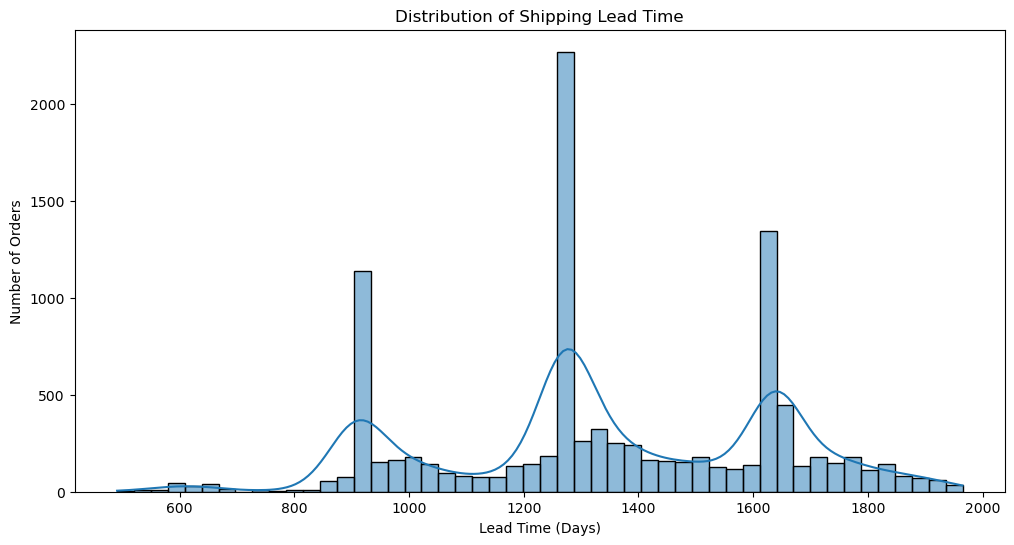

In [17]:
# Lead time distribution 
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Lead Time",
    bins=50,
    kde=True
)

plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

In [18]:
# Lead Time by shipping mode
df.groupby("Ship Mode")["Lead Time"].agg(
    ["count", "min", "mean", "median", "max"]
).sort_values("mean")

,count,min,mean,median,max
Ship Mode,,,,,
Standard Class,6120,552.00,1336.58,1276.00,1965.00
Second Class,1979,491.00,1352.12,1300.00,1960.00
Same Day,547,727.00,1356.49,1297.00,1929.00
First Class,1548,522.00,1360.13,1299.00,1961.00


In [19]:
# Lead TIme by region
df.groupby("Region")["Lead Time"].agg(
    ["count", "min", "mean", "median", "max"]
).sort_values("mean")

,count,min,mean,median,max
Region,,,,,
Gulf,1620,491.00,1323.10,1275.00,1963.00
Interior,2335,522.00,1343.31,1276.00,1965.00
Pacific,3253,552.00,1349.62,1284.00,1965.00
Atlantic,2986,522.00,1350.57,1299.00,1963.00


In [20]:
# Lead Time by product 
df.groupby("Product Name")["Lead Time"].agg(
    ["count", "min", "mean", "median", "max"]
).sort_values("mean")

,count,min,mean,median,max
Product Name,,,,,
Fun Dip,3,858.00,1165.00,1184.00,1453.00
Fizzy Lifting Drinks,6,847.00,1199.83,1264.50,1640.00
Nerds,4,908.00,1222.75,1172.00,1639.00
Kazookles,96,586.00,1296.99,1275.00,1905.00
Wonka Gum,120,555.00,1308.59,1274.50,1962.00
Hair Toffee,4,981.00,1337.25,1364.50,1639.00
Wonka Bar - Fudge Mallows,1818,491.00,1339.35,1276.00,1965.00
Wonka Bar - Milk Chocolate,2137,522.00,1339.90,1276.00,1965.00
Wonka Bar -Scrumdiddlyumptious,2064,522.00,1343.43,1276.00,1965.00


In [21]:
df[["Order Date", "Ship Date", "Lead Time"]].agg(
    ["min", "max"]
)

,Order Date,Ship Date,Lead Time
min,2024-01-02,2026-01-07,491.00
max,2025-12-31,2030-12-06,1965.00


In [22]:
# Normalize Numerical Features

from sklearn.preprocessing import StandardScaler

# Numerical features selected for preprocessing
numerical_features = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost"
]

print("Numerical features selected for normalization:")
for feature in numerical_features:
    print("-", feature)

Numerical features selected for normalization:
- Sales
- Units
- Gross Profit
- Cost


In [23]:
# Check numerical features before normalization

numerical_summary_before = df[numerical_features].describe().T

numerical_summary_before

,count,mean,std,min,25%,50%,75%,max
Sales,10194.00,13.91,11.34,1.25,7.20,10.80,18.00,260.00
Units,10194.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Gross Profit,10194.00,9.17,6.64,0.25,4.90,7.47,12.25,130.00
Cost,10194.00,4.74,5.06,0.60,2.40,3.60,5.70,130.00


In [24]:
# Initialize StandardScaler

scaler = StandardScaler()

# Normalize numerical features

df[numerical_features] = scaler.fit_transform(
    df[numerical_features]
)

print("Numerical features normalized successfully.")

Numerical features normalized successfully.


In [25]:
# Verifying normalization

numerical_summary_after = df[numerical_features].agg(
    ["mean", "std", "min", "max"]
).T

numerical_summary_after

,mean,std,min,max
Sales,-0.00,1.00,-1.12,21.70
Units,0.00,1.00,-1.25,4.58
Gross Profit,0.00,1.00,-1.34,18.19
Cost,-0.00,1.00,-0.82,24.75


In [26]:
# Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Region",
    "Ship Mode"
]

print("Categorical features selected for encoding:")

for feature in categorical_features:
    print("-", feature)

Categorical features selected for encoding:
- Region
- Ship Mode


In [27]:
# Check unique categories before encoding

for feature in categorical_features:
    print(f"\n{feature}:")
    print(df[feature].unique())


Region:
['Interior' 'Atlantic' 'Gulf' 'Pacific']

Ship Mode:
['Standard Class' 'First Class' 'Second Class' 'Same Day']


In [28]:
# Check category frequencies

for feature in categorical_features:
    print(f"\n{feature}")
    print(df[feature].value_counts())


Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: Region, dtype: int64

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: Ship Mode, dtype: int64


In [29]:
# Apply One-Hot Encoding

from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Region",
    "Ship Mode"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_array = encoder.fit_transform(
    df[categorical_features]
)

encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=df.index
)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [30]:
# Display encoded columns

print("Encoded columns:")
print(list(encoded_df.columns))

Encoded columns:
['Region_Atlantic', 'Region_Gulf', 'Region_Interior', 'Region_Pacific', 'Ship Mode_First Class', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class']


In [31]:
encoded_df.head()

,Region_Atlantic,Region_Gulf,Region_Interior,Region_Pacific,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
1,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
2,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [32]:
# Verify dimensions

print("Original rows:", df.shape[0])
print("Encoded feature rows:", encoded_df.shape[0])
print("Number of encoded columns:", encoded_df.shape[1])

Original rows: 10194
Encoded feature rows: 10194
Number of encoded columns: 8


In [33]:
# Remove Extreme Outliers
# Identify Outliers Using IQR Method

outlier_features = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Lead Time"
]

outlier_summary = []

for feature in outlier_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Sales,-0.59,0.36,0.95,-2.02,1.79,245,2.40
1,Units,-0.80,0.54,1.35,-2.82,2.56,175,1.72
2,Gross Profit,-0.64,0.46,1.11,-2.30,2.12,217,2.13
3,Cost,-0.46,0.19,0.65,-1.44,1.17,397,3.89
4,Lead Time,1194.00,1638.00,444.00,528.00,2304.00,11,0.11


In [34]:
# creating outlier mask

outlier_features = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Lead Time"
]

# Start with no outliers
combined_outlier_mask = pd.Series(
    False,
    index=df.index
)

# Identify outliers for each feature
for feature in outlier_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    feature_outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    combined_outlier_mask = (
        combined_outlier_mask |
        feature_outlier_mask
    )

print("Total rows identified as outliers:",
      combined_outlier_mask.sum())

print("Percentage of dataset:",
      round(combined_outlier_mask.mean() * 100, 2), "%")

Total rows identified as outliers: 421
Percentage of dataset: 4.13 %


In [35]:
# Dataset size before and after outlier removal
rows_before = len(df)

df_clean = df.loc[~combined_outlier_mask].copy()

rows_after = len(df_clean)

print("Rows before outlier removal:", rows_before)
print("Rows removed:", rows_before - rows_after)
print("Rows after outlier removal:", rows_after)

Rows before outlier removal: 10194
Rows removed: 421
Rows after outlier removal: 9773


In [36]:
# Compare Lead Time before and after outlier removal

print("Lead Time BEFORE outlier removal:")
print(df["Lead Time"].describe())

print("\nLead Time AFTER outlier removal:")
print(df_clean["Lead Time"].describe())

Lead Time BEFORE outlier removal:
count   10194.00
mean     1344.24
std       294.68
min       491.00
25%      1194.00
50%      1276.00
75%      1638.00
max      1965.00
Name: Lead Time, dtype: float64

Lead Time AFTER outlier removal:
count   9773.00
mean    1344.77
std      292.67
min      552.00
25%     1202.00
50%     1276.00
75%     1638.00
max     1965.00
Name: Lead Time, dtype: float64


In [37]:
# Check remaining Lead Time outliers
Q1 = df_clean["Lead Time"].quantile(0.25)
Q3 = df_clean["Lead Time"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

remaining_leadtime_outliers = (
    (df_clean["Lead Time"] < lower_bound) |
    (df_clean["Lead Time"] > upper_bound)
).sum()

print("Remaining Lead Time outliers:",
      remaining_leadtime_outliers)

Remaining Lead Time outliers: 0


In [38]:
# Create training-ready feature mix
# Product > Current Factory Mapping
product_factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

print("Number of product-factory mappings:",      len(product_factory_mapping))

Number of product-factory mappings: 15


In [39]:
# Add current factory assignment
df_clean["Origin Factory"] = (
    df_clean["Product Name"]
    .map(product_factory_mapping)
)

print("Origin Factory mapping completed.")

Origin Factory mapping completed.


In [40]:
# Validate the mapping
print(
    "Missing Origin Factory:",
    df_clean["Origin Factory"].isna().sum()
)

Missing Origin Factory: 0


In [41]:
# Check factory distribution
df_clean["Origin Factory"].value_counts()

Lot's O' Nuts        5553
Wicked Choccy's      4014
Secret Factory        119
The Other Factory      54
Sugar Shack            33
Name: Origin Factory, dtype: int64

In [42]:
# Check Product → Factory assignments
df_clean[
    ["Product Name", "Origin Factory"]
].drop_duplicates().sort_values("Product Name")

,Product Name,Origin Factory
191,Fizzy Lifting Drinks,Sugar Shack
5007,Fun Dip,Sugar Shack
4435,Hair Toffee,The Other Factory
26,Kazookles,The Other Factory
226,Laffy Taffy,Sugar Shack
3155,Lickable Wallpaper,Secret Factory
1490,Nerds,Sugar Shack
973,SweeTARTS,Sugar Shack
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts
0,Wonka Bar - Milk Chocolate,Wicked Choccy's


#### The categorical features below are selected based on the predictive modeling objective, which aims to predict shipping lead time using product, origin factory, destination region, and ship mode

In [43]:
# Select Predictive Categorical Features
model_categorical_features = [
    "Product Name",
    "Origin Factory",
    "Region",
    "Ship Mode"
]

print("Categorical predictors selected for the model:")

for feature in model_categorical_features:
    print("-", feature)

Categorical predictors selected for the model:
- Product Name
- Origin Factory
- Region
- Ship Mode


In [44]:
# # One-Hot Encode Model Categorical Features
# model_encoder = OneHotEncoder(
#     handle_unknown="ignore",
#     sparse_output=False
# )

# model_encoded_array = model_encoder.fit_transform(
#     df_clean[model_categorical_features]
# )

# model_encoded_columns = (
#     model_encoder.get_feature_names_out(
#         model_categorical_features
#     )
# )

# model_encoded_df = pd.DataFrame(
#     model_encoded_array,
#     columns=model_encoded_columns,
#     index=df_clean.index
# )

# print("Model categorical variables encoded successfully.")
# print(
#     "Number of encoded features:",
#     model_encoded_df.shape[1]
# )


# One-Hot Encode Model Categorical Features
# Drop the first category of each variable to avoid
# the dummy-variable trap and multicollinearity.

model_encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

model_encoded_array = model_encoder.fit_transform(
    df_clean[model_categorical_features]
)

model_encoded_columns = (
    model_encoder.get_feature_names_out(
        model_categorical_features
    )
)

model_encoded_df = pd.DataFrame(
    model_encoded_array,
    columns=model_encoded_columns,
    index=df_clean.index
)

print("Model categorical variables encoded successfully.")
print(
    "Number of encoded features:",
    model_encoded_df.shape[1]
)

Model categorical variables encoded successfully.
Number of encoded features: 23


In [45]:
# Display encoded feature names
print("Encoded feature columns:")

for column in model_encoded_df.columns:
    print("*",column)

Encoded feature columns:
* Product Name_Fun Dip
* Product Name_Hair Toffee
* Product Name_Kazookles
* Product Name_Laffy Taffy
* Product Name_Lickable Wallpaper
* Product Name_Nerds
* Product Name_SweeTARTS
* Product Name_Wonka Bar - Fudge Mallows
* Product Name_Wonka Bar - Milk Chocolate
* Product Name_Wonka Bar - Nutty Crunch Surprise
* Product Name_Wonka Bar - Triple Dazzle Caramel
* Product Name_Wonka Bar -Scrumdiddlyumptious
* Product Name_Wonka Gum
* Origin Factory_Secret Factory
* Origin Factory_Sugar Shack
* Origin Factory_The Other Factory
* Origin Factory_Wicked Choccy's
* Region_Gulf
* Region_Interior
* Region_Pacific
* Ship Mode_Same Day
* Ship Mode_Second Class
* Ship Mode_Standard Class


In [46]:
# Define Target Variable
y = df_clean["Lead Time"].copy()

print("Target variable: Lead Time")
print("Target observations:", len(y))

Target variable: Lead Time
Target observations: 9773


In [47]:
# Create Training-Ready Feature Matrix
X = model_encoded_df.copy()

print("Training-ready feature matrix created.")
print("Rows:", X.shape[0])
print("Columns:", X.shape[1])

Training-ready feature matrix created.
Rows: 9773
Columns: 23


In [48]:
# Final Training Data Validation
print("Training Data Validation")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:",
      X.isna().sum().sum())

print("Missing values in y:",
      y.isna().sum())

print("\nTarget statistics:")
print(y.describe())

Training Data Validation
X shape: (9773, 23)
y shape: (9773,)

Missing values in X: 0
Missing values in y: 0

Target statistics:
count   9773.00
mean    1344.77
std      292.67
min      552.00
25%     1202.00
50%     1276.00
75%     1638.00
max     1965.00
Name: Lead Time, dtype: float64


####  
The objective is to predict expected shipping lead time using Product, Origin Factory, Destination Region, and Ship Mode. Three regression models specified in the technical documentation will be evaluated to identify the best-performing model. Moreover, in here below, there's an 80:20 split has been done.   

### 2. Predictive Modeling Objective

In [49]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training and testing datasets created successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Training and testing datasets created successfully.
X_train shape: (7818, 23)
X_test shape : (1955, 23)
y_train shape: (7818,)
y_test shape : (1955,)


#### Linear Regression
 It is used as the baseline model to establish a simple reference level of predictive performance against which the more flexible ensemble models can be compared.

In [50]:
# Linear Regression - Baseline Model
from sklearn.linear_model import LinearRegression

# Initialize the baseline model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [51]:
# Generate predictions on the test set
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression predictions generated successfully.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression predictions generated successfully.
Number of predictions: 1955


In [52]:
# Linear Regression Evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")
print(f"RMSE: {rmse_linear:.2f}")
print(f"MAE : {mae_linear:.2f}")
print(f"R²  : {r2_linear:.4f}")

Linear Regression Performance
RMSE: 293.44
MAE : 239.82
R²  : -0.0026


#### Inference: 
The Linear Regression baseline demonstrates only limited predictive ability, having an MAE of 239.86 days and an R² of -0.0023. The fact that the R² is so close to zero and negative shows that the model flops to capture any significant variation in shipping lead time on the test data. This baseline will be used as a point of comparison for the Random Forest and Gradient Boosting models.

#### Random Forest Regressor
Random Forest Regressor is evaluated as a nonlinear ensemble model to determine whether it can capture relationships in shipping lead time that are not captured by the Linear Regression baseline.

In [53]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest model
random_forest_model = RandomForestRegressor(
    random_state=42
)

# Train the model
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [54]:
# Generating predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully.
Number of predictions: 1955


In [55]:
# Random Forest Evaluation
rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Regressor Performance")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE : {mae_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest Regressor Performance
RMSE: 294.90
MAE : 240.33
R²  : -0.0126


#### Inference: 
The Random Forest Regressor achieved an RMSE of 294.98 days, MAE of 240.40 days, and R² of -0.0131. Compared with the Linear Regression baseline, the model shows slightly higher prediction errors and a lower R². Therefore, Random Forest does not improve predictive performance over the baseline on the current test dataset.

#### Gradient Boosting Regressor 
It is evaluated as the third specified regression model to determine whether sequentially combined weak learners can provide better shipping lead-time predictions than the baseline and Random Forest models.

In [56]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

# Train the model
gradient_boosting_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting Regressor trained successfully.")

Gradient Boosting Regressor trained successfully.


In [57]:
# Generate predictions on the test set
y_pred_gb = gradient_boosting_model.predict(X_test)

print("Gradient Boosting predictions generated successfully.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting predictions generated successfully.
Number of predictions: 1955


In [58]:
# Gradient Boosting Evaluation
rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Regressor Performance")
print(f"RMSE: {rmse_gb:.2f}")
print(f"MAE : {mae_gb:.2f}")
print(f"R²  : {r2_gb:.4f}")

Gradient Boosting Regressor Performance
RMSE: 293.76
MAE : 240.01
R²  : -0.0048


#### Inference :

-> Among the three regression models that were evaluated, Linear Regression obtained the best overall results on the test set, having the lowest RMSE (293.40 days), the lowest MAE (239.86 days), and the highest R² value of -0.0023. Nevertheless, the differences in performance between the models are minor, and all three models have R² values that are either close to zero or below zero. 

-> This shows that the chosen predictors currently have only a limited ability to explain shipping lead time; since Linear Regression performs best according to the given evaluation criteria, it is the model that is selected, although its limited predictive performance should be taken into account in the subsequent analysis.

In [59]:
# Model Performance Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

model_comparison

,Model,RMSE,MAE,R²
0,Linear Regression,293.44,239.82,-0.00
1,Random Forest,294.90,240.33,-0.01
2,Gradient Boosting,293.76,240.01,-0.00


In [60]:
# Identify the model with the lowest RMSE
best_model_name = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

print("Best-performing model based on RMSE:",
      best_model_name)

Best-performing model based on RMSE: Linear Regression


#### Inference:
Of the three regression models examined, Linear Regression obtained the best overall results, having an RMSE of 293.40 days, a MAE of 239.86 days, and an R² of -0.0023. Yet all three models showed a similar level of performance with R² values being either close to zero or below it, which shows that the current set of predictors has only limited predictive power. The Linear Regression model is therefore regarded as the best-performing one on the basis of the given evaluation criteria.

### 4. Route & Product Clustering


#### 
Routes are represented as Origin Factory–Destination Region combinations. Route-level shipping performance is summarized using shipping lead time to identify differences in operational performance before clustering.

In [61]:
# Route-Level Performance Analysis
route_performance = (
    df_clean
    .groupby(["Origin Factory", "Region"])["Lead Time"]
    .agg(
        Order_Count="count",
        Mean_Lead_Time="mean",
        Median_Lead_Time="median",
        Min_Lead_Time="min",
        Max_Lead_Time="max"
    )
    .reset_index()
)

route_performance = route_performance.sort_values(
    "Mean_Lead_Time",
    ascending=False
)

route_performance

,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
11,Sugar Shack,Pacific,3,1575.67,1638.00,1274.00,1815.00
8,Sugar Shack,Atlantic,18,1390.67,1382.00,908.00,1820.00
4,Secret Factory,Atlantic,37,1375.49,1300.00,907.00,1962.00
13,The Other Factory,Gulf,8,1362.25,1449.50,937.00,1638.00
19,Wicked Choccy's,Pacific,1294,1353.22,1301.00,583.00,1965.00
0,Lot's O' Nuts,Atlantic,1617,1352.59,1302.00,553.00,1963.00
15,The Other Factory,Pacific,18,1350.94,1276.00,908.00,1901.00
2,Lot's O' Nuts,Interior,1305,1347.15,1302.00,552.00,1965.00
16,Wicked Choccy's,Atlantic,1161,1346.13,1276.00,553.00,1962.00
3,Lot's O' Nuts,Pacific,1761,1344.61,1276.00,552.00,1965.00


In [62]:
route_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
] = route_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
].round(2)

route_performance

,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
11,Sugar Shack,Pacific,3,1575.67,1638.00,1274.00,1815.00
8,Sugar Shack,Atlantic,18,1390.67,1382.00,908.00,1820.00
4,Secret Factory,Atlantic,37,1375.49,1300.00,907.00,1962.00
13,The Other Factory,Gulf,8,1362.25,1449.50,937.00,1638.00
19,Wicked Choccy's,Pacific,1294,1353.22,1301.00,583.00,1965.00
0,Lot's O' Nuts,Atlantic,1617,1352.59,1302.00,553.00,1963.00
15,The Other Factory,Pacific,18,1350.94,1276.00,908.00,1901.00
2,Lot's O' Nuts,Interior,1305,1347.15,1302.00,552.00,1965.00
16,Wicked Choccy's,Atlantic,1161,1346.13,1276.00,553.00,1962.00
3,Lot's O' Nuts,Pacific,1761,1344.61,1276.00,552.00,1965.00


In [63]:
# Number of unique factory-region routes
print(
    "Number of unique routes:",
    route_performance.shape[0]
)

Number of unique routes: 20


In [64]:
# Orders represented in route analysis
print(
    "Total orders represented:",
    route_performance["Order_Count"].sum()
)

print(
    "Cleaned dataset rows:",
    len(df_clean)
)

Total orders represented: 9773
Cleaned dataset rows: 9773


In [65]:
route_performance

,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
11,Sugar Shack,Pacific,3,1575.67,1638.00,1274.00,1815.00
8,Sugar Shack,Atlantic,18,1390.67,1382.00,908.00,1820.00
4,Secret Factory,Atlantic,37,1375.49,1300.00,907.00,1962.00
13,The Other Factory,Gulf,8,1362.25,1449.50,937.00,1638.00
19,Wicked Choccy's,Pacific,1294,1353.22,1301.00,583.00,1965.00
0,Lot's O' Nuts,Atlantic,1617,1352.59,1302.00,553.00,1963.00
15,The Other Factory,Pacific,18,1350.94,1276.00,908.00,1901.00
2,Lot's O' Nuts,Interior,1305,1347.15,1302.00,552.00,1965.00
16,Wicked Choccy's,Atlantic,1161,1346.13,1276.00,553.00,1962.00
3,Lot's O' Nuts,Pacific,1761,1344.61,1276.00,552.00,1965.00


#### Route Clustering by Performance Similarity :-
Routes are clustered based on their observed shipping lead-time characteristics to identify groups with similar operational performance.

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [67]:
# Route Clustering by Performance Similarity
clustering_features = [
    "Mean_Lead_Time",
    "Median_Lead_Time",
    "Min_Lead_Time",
    "Max_Lead_Time"
]

route_clustering_data = route_performance[
    clustering_features
].copy()

scaler = StandardScaler()

route_clustering_scaled = scaler.fit_transform(
    route_clustering_data
)

print("Route-level clustering features standardized successfully.")
print("Clustering observations:", route_clustering_scaled.shape[0])
print("Clustering features:", route_clustering_scaled.shape[1])

Route-level clustering features standardized successfully.
Clustering observations: 20
Clustering features: 4


In [68]:
# Selecting the Number of Route Clusters
inertia_values = []

cluster_range = range(2, 8)

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(route_clustering_scaled)
    
    inertia_values.append(kmeans.inertia_)

print("Inertia values:")
for k, inertia in zip(cluster_range, inertia_values):
    print(f"k = {k}: {inertia:.2f}")

Inertia values:
k = 2: 45.50
k = 3: 25.95
k = 4: 12.59
k = 5: 7.73
k = 6: 4.73
k = 7: 3.09


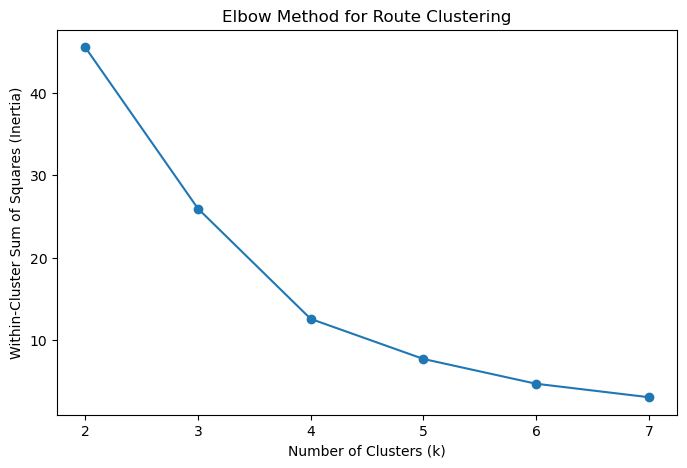

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Route Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(cluster_range))
plt.show()

#### Inference: 
The Elbow Method indicates that four clusters provide a reasonable balance between within-cluster similarity and model simplicity. Therefore, four clusters are selected for route performance segmentation.

In [70]:
# Route Clustering
kmeans_route = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

route_performance["Route_Cluster"] = kmeans_route.fit_predict(
    route_clustering_scaled
)

print("Route clustering completed successfully.")
print(
    "Number of clusters:",
    route_performance["Route_Cluster"].nunique()
)

Route clustering completed successfully.
Number of clusters: 4


In [71]:
# View routes with their assigned clusters
route_clustered = route_performance.sort_values(
    ["Route_Cluster", "Mean_Lead_Time"],
    ascending=[True, False]
).reset_index(drop=True)

route_clustered

,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time,Route_Cluster
0,Sugar Shack,Atlantic,18,1390.67,1382.00,908.00,1820.00,0
1,Secret Factory,Atlantic,37,1375.49,1300.00,907.00,1962.00,0
2,The Other Factory,Gulf,8,1362.25,1449.50,937.00,1638.00,0
3,The Other Factory,Pacific,18,1350.94,1276.00,908.00,1901.00,0
4,Sugar Shack,Interior,8,1307.38,1272.50,847.00,1700.00,0
5,Secret Factory,Interior,30,1293.63,1273.00,847.00,1845.00,0
6,The Other Factory,Atlantic,20,1255.25,1275.00,907.00,1875.00,0
7,The Other Factory,Interior,8,1110.50,937.00,889.00,1756.00,1
8,Sugar Shack,Gulf,4,1069.25,1046.50,909.00,1275.00,1
9,Wicked Choccy's,Pacific,1294,1353.22,1301.00,583.00,1965.00,2


In [72]:
# Cluster-Level Performance Summary
cluster_summary = (
    route_performance
    .groupby("Route_Cluster")
    .agg(
        Number_of_Routes=("Route_Cluster", "count"),
        Total_Orders=("Order_Count", "sum"),
        Average_Mean_Lead_Time=("Mean_Lead_Time", "mean"),
        Average_Median_Lead_Time=("Median_Lead_Time", "mean"),
        Average_Min_Lead_Time=("Min_Lead_Time", "mean"),
        Average_Max_Lead_Time=("Max_Lead_Time", "mean")
    )
    .sort_values(
        "Average_Mean_Lead_Time",
        ascending=False
    )
)

cluster_summary.round(2)

,Number_of_Routes,Total_Orders,Average_Mean_Lead_Time,Average_Median_Lead_Time,Average_Min_Lead_Time,Average_Max_Lead_Time
Route_Cluster,,,,,,
3,1,3,1575.67,1638.00,1274.00,1815.00
2,10,9619,1336.35,1294.15,568.30,1942.70
0,7,139,1333.66,1318.29,894.43,1820.14
1,2,12,1089.88,991.75,899.00,1515.50


#### Inference -
What the clustering shows is a single route having a very long lead time and based on only a limited number of observations, a second group with a shorter lead time and also based on limited observations, and two larger groups which have generally similar lead-time features. There is no large, clearly distinct "consistently slow" cluster apparent in the current route-level data.

In [73]:
# Identify Potentially Slow Routes
slow_route_candidates = (
    route_performance[
        route_performance["Order_Count"] >= 100
    ]
    .sort_values(
        "Mean_Lead_Time",
        ascending=False
    )
)

slow_route_candidates[
    [
        "Origin Factory",
        "Region",
        "Order_Count",
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time",
        "Route_Cluster"
    ]
]

,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time,Route_Cluster
19,Wicked Choccy's,Pacific,1294,1353.22,1301.00,583.00,1965.00,2
0,Lot's O' Nuts,Atlantic,1617,1352.59,1302.00,553.00,1963.00,2
2,Lot's O' Nuts,Interior,1305,1347.15,1302.00,552.00,1965.00,2
16,Wicked Choccy's,Atlantic,1161,1346.13,1276.00,553.00,1962.00,2
3,Lot's O' Nuts,Pacific,1761,1344.61,1276.00,552.00,1965.00,2
18,Wicked Choccy's,Interior,919,1344.37,1276.00,583.00,1964.00,2
1,Lot's O' Nuts,Gulf,870,1334.06,1276.00,583.00,1963.00,2
17,Wicked Choccy's,Gulf,640,1325.08,1276.00,555.00,1934.00,2


### Inference : 
The analysis shows there to be no single route that is clearly separated out and consistently has a slow high volume. Nevertheless, Wicked Choccy's to Pacific and Lot's O' Nuts to Atlantic have the highest mean Lead Times of all the routes for which there is sufficient representation and may therefore be regarded as priority routes for further scenario analysis.

In [74]:
# Region–Product Performance Analysis
region_product_performance = (
    df_clean
    .groupby(["Product Name", "Region"])["Lead Time"]
    .agg(
        Order_Count="count",
        Mean_Lead_Time="mean",
        Median_Lead_Time="median",
        Min_Lead_Time="min",
        Max_Lead_Time="max"
    )
    .reset_index()
)

region_product_performance = region_product_performance.sort_values(
    "Mean_Lead_Time",
    ascending=False
)

region_product_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
] = region_product_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
].round(2)

region_product_performance

,Product Name,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
19,Lickable Wallpaper,Interior,1,1818.00,1818.00,1818.00,1818.00
23,SweeTARTS,Pacific,1,1815.00,1815.00,1815.00,1815.00
7,Hair Toffee,Atlantic,1,1639.00,1639.00,1639.00,1639.00
17,Laffy Taffy,Pacific,1,1638.00,1638.00,1638.00,1638.00
8,Hair Toffee,Gulf,1,1576.00,1576.00,1576.00,1576.00
14,Laffy Taffy,Atlantic,6,1520.83,1558.50,1273.00,1820.00
18,Lickable Wallpaper,Atlantic,3,1482.67,1478.00,1332.00,1638.00
22,SweeTARTS,Interior,4,1460.50,1435.00,1272.00,1700.00
4,Fun Dip,Atlantic,1,1453.00,1453.00,1453.00,1453.00
21,SweeTARTS,Atlantic,5,1406.80,1450.00,910.00,1759.00


In [75]:
# Checking number of Product-region combinations we have
print(
    "Number of Product-Region combinations:",
    region_product_performance.shape[0]
)

print(
    "Total orders represented:",
    region_product_performance["Order_Count"].sum()
)

Number of Product-Region combinations: 48
Total orders represented: 9773


In [76]:
# Identify Potentially Congested Region-Product Combinations
region_product_candidates = (
    region_product_performance[
        region_product_performance["Order_Count"] >= 100
    ]
    .sort_values(
        "Mean_Lead_Time",
        ascending=False
    )
)

region_product_candidates[
    [
        "Product Name",
        "Region",
        "Order_Count",
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
]

,Product Name,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
32,Wonka Bar - Nutty Crunch Surprise,Atlantic,482,1381.79,1333.00,583.00,1963.00
36,Wonka Bar - Triple Dazzle Caramel,Atlantic,535,1360.71,1303.00,553.00,1961.00
42,Wonka Bar -Scrumdiddlyumptious,Interior,455,1356.75,1316.00,553.00,1965.00
30,Wonka Bar - Milk Chocolate,Interior,492,1356.03,1302.00,583.00,1964.00
43,Wonka Bar -Scrumdiddlyumptious,Pacific,660,1354.11,1276.00,552.00,1962.00
39,Wonka Bar - Triple Dazzle Caramel,Pacific,646,1353.84,1302.00,583.00,1963.00
31,Wonka Bar - Milk Chocolate,Pacific,648,1352.60,1300.50,583.00,1965.00
34,Wonka Bar - Nutty Crunch Surprise,Interior,449,1348.81,1302.00,552.00,1964.00
24,Wonka Bar - Fudge Mallows,Atlantic,526,1347.89,1276.00,585.00,1963.00
37,Wonka Bar - Triple Dazzle Caramel,Gulf,312,1344.96,1302.00,614.00,1934.00


#### Inference: 
Product–Region combinations show considerable variation in observed Lead Time, but combinations with very small order counts should be interpreted cautiously because their mean Lead Time is based on limited observations.

### 5. Scenario Simulation Engine


In [77]:
# Scenario Simulation Inputs
scenario_columns = [
    "Product Name",
    "Origin Factory",
    "Region",
    "Ship Mode"
]

scenario_data = df_clean[scenario_columns].copy()

print("Scenario input dataset created successfully.")
print(f"Rows: {scenario_data.shape[0]:,}")
print(f"Columns: {scenario_data.shape[1]}")

Scenario input dataset created successfully.
Rows: 9,773
Columns: 4


In [78]:
# Identify Alternative Factories
factory_options = [
    "Lot's O' Nuts",
    "Wicked Choccy's",
    "Sugar Shack",
    "Secret Factory",
    "The Other Factory"
]

print("Available factories for scenario simulation:")
for factory in factory_options:
    print("*", factory)

print(f"\nTotal factories available: {len(factory_options)}")

Available factories for scenario simulation:
* Lot's O' Nuts
* Wicked Choccy's
* Sugar Shack
* Secret Factory
* The Other Factory

Total factories available: 5


In [79]:
# Generate Factory Assignment Scenarios
scenario_records = []

for _, row in scenario_data.iterrows():

    for factory in factory_options:

        scenario_records.append({
            "Product Name": row["Product Name"],
            "Current Factory": row["Origin Factory"],
            "Scenario Factory": factory,
            "Region": row["Region"],
            "Ship Mode": row["Ship Mode"]
        })

scenario_df = pd.DataFrame(scenario_records)

print("Factory assignment scenarios generated successfully.")
print(f"Original observations: {len(scenario_data):,}")
print(f"Scenario observations: {len(scenario_df):,}")
print(f"Scenario columns: {scenario_df.shape[1]}")

Factory assignment scenarios generated successfully.
Original observations: 9,773
Scenario observations: 48,865
Scenario columns: 5


#### Inference  
The scenario engine has successfully expanded each cleaned observation into five possible factory-assignment scenarios. The current factory is included as a baseline, allowing us to compare the current assignment with each alternative factory later.

In [80]:
# Check Model Feature Structure
print("Model input feature count:", X_train.shape[1])
print("\nModel feature columns:")
for col in X_train.columns:
    print("-", col)

Model input feature count: 23

Model feature columns:
- Product Name_Fun Dip
- Product Name_Hair Toffee
- Product Name_Kazookles
- Product Name_Laffy Taffy
- Product Name_Lickable Wallpaper
- Product Name_Nerds
- Product Name_SweeTARTS
- Product Name_Wonka Bar - Fudge Mallows
- Product Name_Wonka Bar - Milk Chocolate
- Product Name_Wonka Bar - Nutty Crunch Surprise
- Product Name_Wonka Bar - Triple Dazzle Caramel
- Product Name_Wonka Bar -Scrumdiddlyumptious
- Product Name_Wonka Gum
- Origin Factory_Secret Factory
- Origin Factory_Sugar Shack
- Origin Factory_The Other Factory
- Origin Factory_Wicked Choccy's
- Region_Gulf
- Region_Interior
- Region_Pacific
- Ship Mode_Same Day
- Ship Mode_Second Class
- Ship Mode_Standard Class


In [81]:
# # Encode Scenario Features
# scenario_categorical = scenario_df[
#     ["Product Name", "Scenario Factory", "Region", "Ship Mode"]
# ].copy()

# # Rename Scenario Factory to match the model's expected predictor name
# scenario_categorical = scenario_categorical.rename(
#     columns={"Scenario Factory": "Origin Factory"}
# )

# # One-hot encode categorical variables
# scenario_encoded = pd.get_dummies(
#     scenario_categorical,
#     columns=[
#         "Product Name",
#         "Origin Factory",
#         "Region",
#         "Ship Mode"
#     ],
#     dtype=float
# )

# # Align scenario features with the trained model's feature structure
# scenario_X = scenario_encoded.reindex(
#     columns=X_train.columns,
#     fill_value=0
# )

# print("Scenario features encoded successfully.")
# print(f"Scenario rows: {scenario_X.shape[0]:,}")
# print(f"Scenario columns: {scenario_X.shape[1]}")
# print(f"Missing values in scenario features: {scenario_X.isna().sum().sum()}")


# Encode Scenario Features Using the SAME Encoder
# used during model training

scenario_categorical = scenario_df[
    [
        "Product Name",
        "Scenario Factory",
        "Region",
        "Ship Mode"
    ]
].copy()

# Rename Scenario Factory to match the training feature name
scenario_categorical = scenario_categorical.rename(
    columns={
        "Scenario Factory": "Origin Factory"
    }
)

# Transform using the SAME fitted encoder
scenario_encoded_array = model_encoder.transform(
    scenario_categorical[
        model_categorical_features
    ]
)

# Convert to DataFrame using the same feature names
scenario_X = pd.DataFrame(
    scenario_encoded_array,
    columns=model_encoder.get_feature_names_out(
        model_categorical_features
    ),
    index=scenario_df.index
)

print("Scenario features encoded successfully.")
print(f"Scenario rows: {scenario_X.shape[0]:,}")
print(f"Scenario columns: {scenario_X.shape[1]}")
print(
    "Missing values in scenario features:",
    scenario_X.isna().sum().sum()
)



Scenario features encoded successfully.
Scenario rows: 48,865
Scenario columns: 23
Missing values in scenario features: 0


In [82]:
# Ridge Regression for Stable Scenario Prediction

from sklearn.linear_model import Ridge

# Initialize Ridge Regression
ridge_model = Ridge(
    alpha=10.0
)

# Train Ridge Regression using the same training data
ridge_model.fit(
    X_train,
    y_train
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [83]:
# # Predict Lead Time for Each Factory Scenario
# scenario_df["Predicted Lead Time"] = linear_model.predict(scenario_X)

# print("Scenario lead-time predictions generated successfully.")
# print(f"Number of scenario predictions: {len(scenario_df):,}")

# print("\nPredicted Lead Time Summary:")
# print(
#     scenario_df["Predicted Lead Time"].describe()
# )

# Predict Lead Time for Each Factory Scenario using Ridge Regression

scenario_df["Predicted Lead Time"] = ridge_model.predict(
    scenario_X
)

print("Scenario lead-time predictions generated successfully.")
print(f"Number of scenario predictions: {len(scenario_df):,}")

print("\nPredicted Lead Time Summary:")
print(
    scenario_df["Predicted Lead Time"].describe()
)

Scenario lead-time predictions generated successfully.
Number of scenario predictions: 48,865

Predicted Lead Time Summary:
count   48865.00
mean     1338.62
std        23.95
min      1259.36
25%      1322.68
50%      1339.09
75%      1355.67
max      1435.71
Name: Predicted Lead Time, dtype: float64


In [84]:
# Validate Scenario Predictions
print("Scenario Prediction Validation")

print(
    "Missing predictions:",
    scenario_df["Predicted Lead Time"].isna().sum()
)

print(
    "Negative predictions:",
    (scenario_df["Predicted Lead Time"] < 0).sum()
)

print("\nPrediction Summary:")
print(
    scenario_df["Predicted Lead Time"].describe()
)

Scenario Prediction Validation
Missing predictions: 0
Negative predictions: 0

Prediction Summary:
count   48865.00
mean     1338.62
std        23.95
min      1259.36
25%      1322.68
50%      1339.09
75%      1355.67
max      1435.71
Name: Predicted Lead Time, dtype: float64


In [85]:
# Identify Best Factory for Each Scenario
scenario_comparison = scenario_df.copy()

# Find the factory with the lowest predicted lead time
best_factory_by_scenario = (
    scenario_comparison
    .groupby(
        [
            "Product Name",
            "Current Factory",
            "Region",
            "Ship Mode"
        ]
    )["Predicted Lead Time"]
    .idxmin()
)

best_factory_scenarios = (
    scenario_comparison.loc[
        best_factory_by_scenario
    ]
    .reset_index(drop=True)
)

print("Best factory identified for each scenario.")
print(
    "Number of unique Product–Current Factory–Region–Ship Mode scenarios:",
    len(best_factory_scenarios)
)

best_factory_scenarios.head(20)

Best factory identified for each scenario.
Number of unique Product–Current Factory–Region–Ship Mode scenarios: 138


,Product Name,Current Factory,Scenario Factory,Region,Ship Mode,Predicted Lead Time
0,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Atlantic,First Class,1321.53
1,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Atlantic,Standard Class,1300.31
2,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Gulf,Standard Class,1282.44
3,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Interior,First Class,1312.04
4,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Interior,Standard Class,1290.82
5,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Pacific,Standard Class,1296.00
6,Fun Dip,Sugar Shack,The Other Factory,Atlantic,Standard Class,1271.96
7,Fun Dip,Sugar Shack,The Other Factory,Gulf,Second Class,1274.76
8,Fun Dip,Sugar Shack,The Other Factory,Interior,Second Class,1283.14
9,Hair Toffee,The Other Factory,The Other Factory,Atlantic,Standard Class,1284.05


In [86]:
# Compare Current Factory with Recommended Factory
# Select the rows where the scenario factory is the actual current factory
current_factory_scenarios = scenario_df[
    scenario_df["Scenario Factory"] == scenario_df["Current Factory"]
].copy()

# Rename only the prediction column
current_factory_scenarios = current_factory_scenarios.rename(
    columns={
        "Predicted Lead Time": "Current Predicted Lead Time"
    }
)

# Keep only the columns required for comparison
current_factory_scenarios = current_factory_scenarios[
    [
        "Product Name",
        "Current Factory",
        "Region",
        "Ship Mode",
        "Current Predicted Lead Time"
    ]
]

# Merge current-factory predictions with best-factory predictions
factory_comparison = best_factory_scenarios.merge(
    current_factory_scenarios,
    on=[
        "Product Name",
        "Current Factory",
        "Region",
        "Ship Mode"
    ],
    how="left"
)

# Calculate predicted improvement
factory_comparison["Predicted Improvement"] = (
    factory_comparison["Current Predicted Lead Time"]
    - factory_comparison["Predicted Lead Time"]
)

# Calculate percentage improvement
factory_comparison["Improvement Percentage"] = (
    factory_comparison["Predicted Improvement"]
    / factory_comparison["Current Predicted Lead Time"]
) * 100

print("Current vs recommended factory comparison completed.")
print(
    "Number of scenarios compared:",
    len(factory_comparison)
)

factory_comparison.head(20)

Current vs recommended factory comparison completed.
Number of scenarios compared: 9773


,Product Name,Current Factory,Scenario Factory,Region,Ship Mode,Predicted Lead Time,Current Predicted Lead Time,Predicted Improvement,Improvement Percentage
0,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Atlantic,First Class,1321.53,1341.20,19.67,1.47
1,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Atlantic,Standard Class,1300.31,1319.98,19.67,1.49
2,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Gulf,Standard Class,1282.44,1302.12,19.67,1.51
3,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Interior,First Class,1312.04,1331.72,19.67,1.48
4,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Interior,Standard Class,1290.82,1310.50,19.67,1.50
5,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,Pacific,Standard Class,1296.00,1315.67,19.67,1.50
6,Fun Dip,Sugar Shack,The Other Factory,Atlantic,Standard Class,1271.96,1291.64,19.67,1.52
7,Fun Dip,Sugar Shack,The Other Factory,Gulf,Second Class,1274.76,1294.43,19.67,1.52
8,Fun Dip,Sugar Shack,The Other Factory,Interior,Second Class,1283.14,1302.81,19.67,1.51
9,Hair Toffee,The Other Factory,The Other Factory,Atlantic,Standard Class,1284.05,1284.05,0.00,0.00


In [87]:
# Validate Factory Recommendation Results

print("Factory Recommendation Validation")

print(
    "Missing current-factory predictions:",
    factory_comparison["Current Predicted Lead Time"].isna().sum()
)

print(
    "Scenarios with predicted improvement:",
    (
        factory_comparison["Predicted Improvement"] > 0
    ).sum()
)

print(
    "Scenarios with no predicted improvement:",
    (
        factory_comparison["Predicted Improvement"] <= 0
    ).sum()
)

print("\nImprovement Summary:")
print(
    factory_comparison["Predicted Improvement"].describe()
)

Factory Recommendation Validation
Missing current-factory predictions: 0
Scenarios with predicted improvement: 9719
Scenarios with no predicted improvement: 54

Improvement Summary:
count   9773.00
mean      38.19
std        5.15
min        0.00
25%       35.00
50%       35.00
75%       42.82
max       53.11
Name: Predicted Improvement, dtype: float64


In [88]:
# Factory Recommendation Summary
# Create a clean recommendation column

factory_comparison["Recommended Factory"] = (
    factory_comparison["Scenario Factory"]
)

# Identify whether a factory change is recommended
factory_comparison["Factory Change Recommended"] = (
    factory_comparison["Recommended Factory"]
    != factory_comparison["Current Factory"]
)

print("Factory recommendation summary created successfully.")

# 1. Overall recommendation summar
total_scenarios = len(factory_comparison)

factory_changes = (
    factory_comparison["Factory Change Recommended"].sum()
)

no_factory_changes = (
    total_scenarios - factory_changes
)

print("\nOverall Recommendation Summary")
print("Total scenarios:", total_scenarios)
print("Scenarios recommending factory change:", factory_changes)
print("Scenarios retaining current factory:", no_factory_changes)

print(
    "Percentage recommending factory change:",
    round(factory_changes / total_scenarios * 100, 2),
    "%"
)

# Most frequently recommended factories
recommended_factory_summary = (
    factory_comparison
    .groupby("Recommended Factory")
    .agg(
        Scenario_Count=("Recommended Factory", "count"),
        Average_Predicted_Lead_Time=("Predicted Lead Time", "mean"),
        Average_Predicted_Improvement=("Predicted Improvement", "mean")
    )
    .sort_values(
        "Scenario_Count",
        ascending=False
    )
)

recommended_factory_summary = (
    recommended_factory_summary.round(2)
)

print("\nRecommended Factory Summary")

display(recommended_factory_summary)

# Factory-to-factory recommendation movements
factory_movements = (
    factory_comparison[
        factory_comparison["Factory Change Recommended"]
    ]
    .groupby(
        [
            "Current Factory",
            "Recommended Factory"
        ]
    )
    .agg(
        Scenario_Count=("Recommended Factory", "count"),
        Average_Improvement=("Predicted Improvement", "mean"),
        Average_Improvement_Percentage=(
            "Improvement Percentage",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Improvement",
        ascending=False
    )
)

factory_movements[
    [
        "Average_Improvement",
        "Average_Improvement_Percentage"
    ]
] = factory_movements[
    [
        "Average_Improvement",
        "Average_Improvement_Percentage"
    ]
].round(2)

print("\nFactory Movement Summary")

display(factory_movements)

Factory recommendation summary created successfully.

Overall Recommendation Summary
Total scenarios: 9773
Scenarios recommending factory change: 9719
Scenarios retaining current factory: 54
Percentage recommending factory change: 99.45 %

Recommended Factory Summary


,Scenario_Count,Average_Predicted_Lead_Time,Average_Predicted_Improvement
Recommended Factory,,,
The Other Factory,9773,1308.50,38.19



Factory Movement Summary


,Current Factory,Recommended Factory,Scenario_Count,Average_Improvement,Average_Improvement_Percentage
1,Secret Factory,The Other Factory,119,53.11,3.97
3,Wicked Choccy's,The Other Factory,4014,42.82,3.18
0,Lot's O' Nuts,The Other Factory,5553,35.00,2.60
2,Sugar Shack,The Other Factory,33,19.67,1.46


#### There's some problem that;s why below code has to run. So I will notify in a comment, right after the problem gets solved.

In [89]:
# Historical Product–Factory relationship

product_factory_history = (
    df_clean
    .groupby(["Product Name", "Origin Factory"])
    .agg(
        Order_Count=("Lead Time", "count"),
        Mean_Lead_Time=("Lead Time", "mean"),
        Median_Lead_Time=("Lead Time", "median")
    )
    .reset_index()
)

print("Unique Product–Factory combinations:",
      product_factory_history.shape[0])

print("\nNumber of factories historically associated with each product:")

product_factory_counts = (
    df_clean
    .groupby("Product Name")["Origin Factory"]
    .nunique()
    .sort_values()
)

print(product_factory_counts)

print("\nProduct–Factory history:")
display(product_factory_history)

Unique Product–Factory combinations: 14

Number of factories historically associated with each product:
Product Name
Fizzy Lifting Drinks                 1
Fun Dip                              1
Hair Toffee                          1
Kazookles                            1
Laffy Taffy                          1
Lickable Wallpaper                   1
Nerds                                1
SweeTARTS                            1
Wonka Bar - Fudge Mallows            1
Wonka Bar - Milk Chocolate           1
Wonka Bar - Nutty Crunch Surprise    1
Wonka Bar - Triple Dazzle Caramel    1
Wonka Bar -Scrumdiddlyumptious       1
Wonka Gum                            1
Name: Origin Factory, dtype: int64

Product–Factory history:


,Product Name,Origin Factory,Order_Count,Mean_Lead_Time,Median_Lead_Time
0,Fizzy Lifting Drinks,Sugar Shack,6,1199.83,1264.50
1,Fun Dip,Sugar Shack,3,1165.00,1184.00
2,Hair Toffee,The Other Factory,4,1337.25,1364.50
3,Kazookles,The Other Factory,50,1277.10,1275.00
4,Laffy Taffy,Sugar Shack,10,1421.90,1378.50
5,Lickable Wallpaper,Secret Factory,4,1566.50,1558.00
6,Nerds,Sugar Shack,4,1222.75,1172.00
7,SweeTARTS,Sugar Shack,10,1469.10,1523.50
8,Wonka Bar - Fudge Mallows,Lot's O' Nuts,1742,1340.46,1276.00
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,2094,1340.48,1276.00


#### Inference :-
From the historical data we see that there is only a single assignment of each product to a factory, which gives rise to 14 distinct Product–Factory pairs involving the 14 products. As a result, there is no historical variation within products with respect to factory assignment from which the predictive model could learn the independent effect of the factory on shipping lead time. It follows that the predictions for alternative factory scenarios derived from the regression model should not be regarded as reliable counterfactual estimates. The scenario analysis will therefore have to use an empirical approach based on factory–region performance rather than depending entirely on regression extrapolation.

In [90]:
# Empirical Factory–Region Performance Lookup
# Used for scenario comparison because historical Product–Factory
# variation is not available for reliable simulated output.
# Building the factory x region perfrormance lookup

factory_region_performance = (
    df_clean
    .groupby(["Origin Factory", "Region"])["Lead Time"]
    .agg(
        Order_Count="count",
        Mean_Lead_Time="mean",
        Median_Lead_Time="median",
        Min_Lead_Time="min",
        Max_Lead_Time="max"
    )
    .reset_index()
)

factory_region_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
] = factory_region_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
].round(2)

print("Factory–Region performance lookup created successfully.")
print(
    "Factory–Region combinations:",
    factory_region_performance.shape[0]
)

factory_region_performance

Factory–Region performance lookup created successfully.
Factory–Region combinations: 20


,Origin Factory,Region,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
0,Lot's O' Nuts,Atlantic,1617,1352.59,1302.00,553.00,1963.00
1,Lot's O' Nuts,Gulf,870,1334.06,1276.00,583.00,1963.00
2,Lot's O' Nuts,Interior,1305,1347.15,1302.00,552.00,1965.00
3,Lot's O' Nuts,Pacific,1761,1344.61,1276.00,552.00,1965.00
4,Secret Factory,Atlantic,37,1375.49,1300.00,907.00,1962.00
5,Secret Factory,Gulf,24,1335.12,1362.50,614.00,1874.00
6,Secret Factory,Interior,30,1293.63,1273.00,847.00,1845.00
7,Secret Factory,Pacific,28,1281.21,1294.00,555.00,1872.00
8,Sugar Shack,Atlantic,18,1390.67,1382.00,908.00,1820.00
9,Sugar Shack,Gulf,4,1069.25,1046.50,909.00,1275.00


In [91]:
# Validating 
print("Factory–Region combinations by factory:")

print(
    factory_region_performance
    .groupby("Origin Factory")["Region"]
    .nunique()
)

print("\nTotal Factory–Region combinations:",
      len(factory_region_performance))

Factory–Region combinations by factory:
Origin Factory
Lot's O' Nuts        4
Secret Factory       4
Sugar Shack          4
The Other Factory    4
Wicked Choccy's      4
Name: Region, dtype: int64

Total Factory–Region combinations: 20


In [92]:
# Empirical Factory–Region–Ship Mode Performance Lookup
# This lookup is used for factory recommendation because
# historical Product–Factory variation is unavailable.

factory_region_shipmode_performance = (
    df_clean
    .groupby(
        [
            "Origin Factory",
            "Region",
            "Ship Mode"
        ]
    )["Lead Time"]
    .agg(
        Order_Count="count",
        Mean_Lead_Time="mean",
        Median_Lead_Time="median",
        Min_Lead_Time="min",
        Max_Lead_Time="max"
    )
    .reset_index()
)

factory_region_shipmode_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
] = factory_region_shipmode_performance[
    [
        "Mean_Lead_Time",
        "Median_Lead_Time",
        "Min_Lead_Time",
        "Max_Lead_Time"
    ]
].round(2)

print(
    "Factory–Region–Ship Mode performance lookup created successfully."
)

print(
    "Factory–Region–Ship Mode combinations:",
    len(factory_region_shipmode_performance)
)

display(factory_region_shipmode_performance)

Factory–Region–Ship Mode performance lookup created successfully.
Factory–Region–Ship Mode combinations: 74


,Origin Factory,Region,Ship Mode,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time
0,Lot's O' Nuts,Atlantic,First Class,292,1360.55,1272.00,847.00,1961.00
1,Lot's O' Nuts,Atlantic,Same Day,88,1347.07,1269.00,904.00,1901.00
2,Lot's O' Nuts,Atlantic,Second Class,295,1373.41,1304.00,553.00,1903.00
3,Lot's O' Nuts,Atlantic,Standard Class,942,1344.12,1302.00,583.00,1963.00
4,Lot's O' Nuts,Gulf,First Class,124,1340.55,1272.00,616.00,1872.00
5,Lot's O' Nuts,Gulf,Same Day,48,1314.33,1269.00,785.00,1871.00
6,Lot's O' Nuts,Gulf,Second Class,176,1392.91,1375.50,858.00,1903.00
7,Lot's O' Nuts,Gulf,Standard Class,522,1314.48,1275.00,583.00,1963.00
8,Lot's O' Nuts,Interior,First Class,163,1370.58,1300.00,828.00,1902.00
9,Lot's O' Nuts,Interior,Same Day,62,1457.79,1490.00,727.00,1870.00


In [93]:
# Validate Factory–Region–Ship Mode Coverage

print("Factory–Region–Ship Mode Coverage")

print(
    "Unique factories:",
    df_clean["Origin Factory"].nunique()
)

print(
    "Unique regions:",
    df_clean["Region"].nunique()
)

print(
    "Unique ship modes:",
    df_clean["Ship Mode"].nunique()
)

print(
    "Observed Factory–Region–Ship Mode combinations:",
    len(factory_region_shipmode_performance)
)

print(
    "Possible combinations:",
    (
        df_clean["Origin Factory"].nunique()
        * df_clean["Region"].nunique()
        * df_clean["Ship Mode"].nunique()
    )
)

Factory–Region–Ship Mode Coverage
Unique factories: 5
Unique regions: 4
Unique ship modes: 4
Observed Factory–Region–Ship Mode combinations: 74
Possible combinations: 80


In [94]:
# Identify Missing Factory–Region–Ship Mode Combinations

all_factory_region_shipmode = pd.MultiIndex.from_product(
    [
        factory_options,
        df_clean["Region"].unique(),
        df_clean["Ship Mode"].unique()
    ],
    names=[
        "Origin Factory",
        "Region",
        "Ship Mode"
    ]
)

observed_factory_region_shipmode = pd.MultiIndex.from_frame(
    factory_region_shipmode_performance[
        [
            "Origin Factory",
            "Region",
            "Ship Mode"
        ]
    ]
)

missing_combinations = (
    all_factory_region_shipmode
    .difference(observed_factory_region_shipmode)
    .to_frame(index=False)
)

print("Missing Factory–Region–Ship Mode combinations:")
print(
    "Number of missing combinations:",
    len(missing_combinations)
)

display(missing_combinations)

Missing Factory–Region–Ship Mode combinations:
Number of missing combinations: 6


,Origin Factory,Region,Ship Mode
0,Sugar Shack,Gulf,First Class
1,Sugar Shack,Gulf,Same Day
2,Sugar Shack,Interior,Same Day
3,Sugar Shack,Pacific,First Class
4,Sugar Shack,Pacific,Same Day
5,The Other Factory,Interior,Same Day


In [95]:
# Assess Factory–Region–Ship Mode Reliability
# Define minimum historical observations required
MIN_OBSERVATIONS = 30

factory_region_shipmode_reliability = (
    factory_region_shipmode_performance.copy()
)

# Classify each combination based on historical sample size
factory_region_shipmode_reliability["Reliability"] = np.select(
    [
        factory_region_shipmode_reliability["Order_Count"] >= MIN_OBSERVATIONS,
        factory_region_shipmode_reliability["Order_Count"] >= 10
    ],
    [
        "High",
        "Moderate"
    ],
    default="Low"
)

print("Factory–Region–Ship Mode reliability assessment completed.")

print("\nReliability distribution:")
print(
    factory_region_shipmode_reliability["Reliability"]
    .value_counts()
)

print("\nFactory–Region–Ship Mode reliability table:")

display(
    factory_region_shipmode_reliability[
        [
            "Origin Factory",
            "Region",
            "Ship Mode",
            "Order_Count",
            "Mean_Lead_Time",
            "Median_Lead_Time",
            "Reliability"
        ]
    ]
)

Factory–Region–Ship Mode reliability assessment completed.

Reliability distribution:
Low         35
High        32
Moderate     7
Name: Reliability, dtype: int64

Factory–Region–Ship Mode reliability table:


,Origin Factory,Region,Ship Mode,Order_Count,Mean_Lead_Time,Median_Lead_Time,Reliability
0,Lot's O' Nuts,Atlantic,First Class,292,1360.55,1272.00,High
1,Lot's O' Nuts,Atlantic,Same Day,88,1347.07,1269.00,High
2,Lot's O' Nuts,Atlantic,Second Class,295,1373.41,1304.00,High
3,Lot's O' Nuts,Atlantic,Standard Class,942,1344.12,1302.00,High
4,Lot's O' Nuts,Gulf,First Class,124,1340.55,1272.00,High
5,Lot's O' Nuts,Gulf,Same Day,48,1314.33,1269.00,High
6,Lot's O' Nuts,Gulf,Second Class,176,1392.91,1375.50,High
7,Lot's O' Nuts,Gulf,Standard Class,522,1314.48,1275.00,High
8,Lot's O' Nuts,Interior,First Class,163,1370.58,1300.00,High
9,Lot's O' Nuts,Interior,Same Day,62,1457.79,1490.00,High


In [96]:
# # Reliable Empirical Scenario Lookup
# # This lookup will be used to estimate scenario lead time
# # using observed Factory–Region–Ship Mode performance.

# reliable_lookup = factory_region_shipmode_performance.copy()

# # Keep only combinations with sufficient empirical reliability
# reliable_lookup = reliable_lookup[
#     reliable_lookup["Reliability"].isin(
#         ["High", "Moderate"]
#     )
# ].copy()

# print("Reliable empirical lookup created successfully.")

# print(
#     "Reliable Factory–Region–Ship Mode combinations:",
#     len(reliable_lookup)
# )

# print("\nReliability distribution:")
# print(
#     reliable_lookup["Reliability"].value_counts()
# )

# display(reliable_lookup.head(20))
# _______________________________________________________________________________________________________________________________

# Reliable Empirical Scenario Lookup
# Use the Factory–Region–Ship Mode performance table
# together with the Reliability classification.

reliable_lookup = factory_region_shipmode_performance.copy()

# Recreate the reliability classification in the lookup
# using the same reliability thresholds used earlier.

def classify_reliability(order_count):
    
    if order_count >= 50:
        return "High"
    
    elif order_count >= 10:
        return "Moderate"
    
    else:
        return "Low"


reliable_lookup["Reliability"] = (
    reliable_lookup["Order_Count"]
    .apply(classify_reliability)
)

# Keep only High and Moderate reliability combinations
reliable_lookup = reliable_lookup[
    reliable_lookup["Reliability"].isin(
        ["High", "Moderate"]
    )
].copy()

print("Reliable empirical lookup created successfully.")

print(
    "Reliable Factory–Region–Ship Mode combinations:",
    len(reliable_lookup)
)

print("\nReliability distribution:")
print(
    reliable_lookup["Reliability"].value_counts()
)

display(reliable_lookup.head(20))

Reliable empirical lookup created successfully.
Reliable Factory–Region–Ship Mode combinations: 39

Reliability distribution:
High        30
Moderate     9
Name: Reliability, dtype: int64


,Origin Factory,Region,Ship Mode,Order_Count,Mean_Lead_Time,Median_Lead_Time,Min_Lead_Time,Max_Lead_Time,Reliability
0,Lot's O' Nuts,Atlantic,First Class,292,1360.55,1272.00,847.00,1961.00,High
1,Lot's O' Nuts,Atlantic,Same Day,88,1347.07,1269.00,904.00,1901.00,High
2,Lot's O' Nuts,Atlantic,Second Class,295,1373.41,1304.00,553.00,1903.00,High
3,Lot's O' Nuts,Atlantic,Standard Class,942,1344.12,1302.00,583.00,1963.00,High
4,Lot's O' Nuts,Gulf,First Class,124,1340.55,1272.00,616.00,1872.00,High
5,Lot's O' Nuts,Gulf,Same Day,48,1314.33,1269.00,785.00,1871.00,Moderate
6,Lot's O' Nuts,Gulf,Second Class,176,1392.91,1375.50,858.00,1903.00,High
7,Lot's O' Nuts,Gulf,Standard Class,522,1314.48,1275.00,583.00,1963.00,High
8,Lot's O' Nuts,Interior,First Class,163,1370.58,1300.00,828.00,1902.00,High
9,Lot's O' Nuts,Interior,Same Day,62,1457.79,1490.00,727.00,1870.00,High


In [97]:
# Scenario Simulation Engine – Product Reallocation Scenarios
# Copy the reliable empirical lookup

scenario_lookup = reliable_lookup.copy()

print("Scenario Simulation Engine initialized successfully.")
print("Reliable scenario combinations available:", len(scenario_lookup))

# Display available factory options
print("\nAvailable origin factories:")
print(sorted(scenario_lookup["Origin Factory"].unique()))

# Display available regions
print("\nAvailable destination regions:")
print(sorted(scenario_lookup["Region"].unique()))

# Display available shipping modes
print("\nAvailable ship modes:")
print(sorted(scenario_lookup["Ship Mode"].unique()))

Scenario Simulation Engine initialized successfully.
Reliable scenario combinations available: 39

Available origin factories:
["Lot's O' Nuts", 'Secret Factory', 'Sugar Shack', 'The Other Factory', "Wicked Choccy's"]

Available destination regions:
['Atlantic', 'Gulf', 'Interior', 'Pacific']

Available ship modes:
['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [98]:
# Product-Level Scenario Base
# Create a product-level dataset for scenario simulation
product_scenario_base = (
    df.groupby(
        ["Product ID", "Product Name", "Region", "Ship Mode"],
        as_index=False
    )
    .agg(
        Order_Count=("Order ID", "count"),
        Current_Mean_Lead_Time=("Lead Time", "mean"),
        Current_Median_Lead_Time=("Lead Time", "median"),
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Total_Cost=("Cost", "sum")
    )
)

print("Product-level scenario base created successfully.")
print("Number of product-region-ship mode scenarios:", len(product_scenario_base))

print("\nSample records:")
display(product_scenario_base.head())

Product-level scenario base created successfully.
Number of product-region-ship mode scenarios: 154

Sample records:


,Product ID,Product Name,Region,Ship Mode,Order_Count,Current_Mean_Lead_Time,Current_Median_Lead_Time,Total_Sales,Total_Gross_Profit,Total_Cost
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,109,1375.50,1272.00,-12.42,-12.39,-11.56
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,22,1384.91,1269.00,-3.17,-3.26,-2.83
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,93,1372.78,1304.00,-0.10,1.37,-2.02
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,324,1328.91,1302.00,-18.97,-16.43,-20.95
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,First Class,39,1305.62,1271.00,-3.39,-3.24,-3.35


In [99]:
# Alternative Factory Scenario Simulation
# Required columns from the reliable empirical lookup
lookup_columns = [
    "Origin Factory",
    "Region",
    "Ship Mode",
    "Order_Count",
    "Mean_Lead_Time",
    "Median_Lead_Time",
    "Reliability"
]

# Keep only the columns required for scenario simulation
factory_options = scenario_lookup[lookup_columns].copy()

# Rename columns to clearly identify simulated factory performance
factory_options = factory_options.rename(
    columns={
        "Order_Count": "Factory_Order_Count",
        "Mean_Lead_Time": "Predicted_Mean_Lead_Time",
        "Median_Lead_Time": "Predicted_Median_Lead_Time",
        "Reliability": "Scenario_Reliability"
    }
)

# Create all product scenarios × reliable factory options
scenario_simulation = product_scenario_base.merge(
    factory_options,
    on=["Region", "Ship Mode"],
    how="left"
)

# Calculate operational improvement
scenario_simulation["Lead_Time_Reduction"] = (
    scenario_simulation["Current_Mean_Lead_Time"]
    - scenario_simulation["Predicted_Mean_Lead_Time"]
)

scenario_simulation["Lead_Time_Reduction_%"] = (
    scenario_simulation["Lead_Time_Reduction"]
    / scenario_simulation["Current_Mean_Lead_Time"]
) * 100

print("Alternative factory scenario simulation completed successfully.")

print(
    "Total simulated product-factory scenarios:",
    len(scenario_simulation)
)

print(
    "Products covered:",
    scenario_simulation["Product ID"].nunique()
)

print("\nScenario reliability distribution:")
print(
    scenario_simulation["Scenario_Reliability"]
    .value_counts(dropna=False)
)

print("\nSample simulated scenarios:")
display(
    scenario_simulation[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Origin Factory",
            "Current_Mean_Lead_Time",
            "Predicted_Mean_Lead_Time",
            "Lead_Time_Reduction",
            "Lead_Time_Reduction_%",
            "Scenario_Reliability"
        ]
    ].head(10)
)

Alternative factory scenario simulation completed successfully.
Total simulated product-factory scenarios: 393
Products covered: 15

Scenario reliability distribution:
High        292
Moderate    101
Name: Scenario_Reliability, dtype: int64

Sample simulated scenarios:


,Product ID,Product Name,Region,Ship Mode,Origin Factory,Current_Mean_Lead_Time,Predicted_Mean_Lead_Time,Lead_Time_Reduction,Lead_Time_Reduction_%,Scenario_Reliability
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,1375.50,1360.55,14.95,1.09,High
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Secret Factory,1375.50,1324.80,50.70,3.69,Moderate
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Wicked Choccy's,1375.50,1353.86,21.64,1.57,High
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Lot's O' Nuts,1384.91,1347.07,37.84,2.73,High
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Wicked Choccy's,1384.91,1293.73,91.18,6.58,High
5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,1372.78,1373.41,-0.63,-0.05,High
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Wicked Choccy's,1372.78,1376.92,-4.14,-0.30,High
7,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,1328.91,1344.12,-15.21,-1.14,High
8,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Secret Factory,1328.91,1374.09,-45.18,-3.40,Moderate
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Sugar Shack,1328.91,1364.93,-36.02,-2.71,Moderate


####  Inference: Scenario Simulation Results

In [100]:
# Inference: Scenario Simulation Results

print("Scenario Simulation Engine — Key Inferences")
print("-" * 55)

print(
    f"1. The simulation evaluated {len(scenario_simulation):,} "
    f"alternative product–factory scenarios across "
    f"{scenario_simulation['Product ID'].nunique()} products."
)

reliability_counts = (
    scenario_simulation["Scenario_Reliability"]
    .value_counts()
)

print(
    f"2. Reliability assessment shows "
    f"{reliability_counts.get('High', 0):,} High-reliability "
    f"and {reliability_counts.get('Moderate', 0):,} "
    f"Moderate-reliability scenarios."
)

improving = (
    scenario_simulation["Lead_Time_Reduction"] > 0
).sum()

worsening = (
    scenario_simulation["Lead_Time_Reduction"] < 0
).sum()

neutral = (
    scenario_simulation["Lead_Time_Reduction"] == 0
).sum()

print(
    f"3. {improving:,} simulated scenarios show a potential "
    f"lead-time improvement, while {worsening:,} show a "
    f"potential deterioration and {neutral:,} are neutral."
)

best_scenario = scenario_simulation.loc[
    scenario_simulation["Lead_Time_Reduction_%"].idxmax()
]

print(
    f"4. The strongest simulated lead-time improvement in "
    f"the evaluated scenarios is "
    f"{best_scenario['Lead_Time_Reduction_%']:.2f}%."
)

print(
    "5. The simulation confirms that factory reassignment "
    "should be evaluated selectively rather than applied "
    "universally."
)

print(
    "6. Reliability and financial-risk information should "
    "therefore be incorporated into the subsequent "
    "optimization and recommendation stage."
)

print(
    "7. Not all possible factory–region–ship mode combinations "
    "are empirically available, so recommendations are limited "
    "to scenarios supported by the observed data."
)

Scenario Simulation Engine — Key Inferences
-------------------------------------------------------
1. The simulation evaluated 393 alternative product–factory scenarios across 15 products.
2. Reliability assessment shows 292 High-reliability and 101 Moderate-reliability scenarios.
3. 188 simulated scenarios show a potential lead-time improvement, while 205 show a potential deterioration and 0 are neutral.
4. The strongest simulated lead-time improvement in the evaluated scenarios is 31.53%.
5. The simulation confirms that factory reassignment should be evaluated selectively rather than applied universally.
6. Reliability and financial-risk information should therefore be incorporated into the subsequent optimization and recommendation stage.
7. Not all possible factory–region–ship mode combinations are empirically available, so recommendations are limited to scenarios supported by the observed data.


In [101]:
# # Profit Sensitivity Analysis
# # Calculate current profit margin

# scenario_simulation["Current_Profit_Margin_%"] = (
#     scenario_simulation["Total_Gross_Profit"]
#     / scenario_simulation["Total_Sales"].replace(0, pd.NA)
# ) * 100

# # Calculate current profit per order
# scenario_simulation["Current_Profit_Per_Order"] = (
#     scenario_simulation["Total_Gross_Profit"]
#     / scenario_simulation["Order_Count"].replace(0, pd.NA)
# )

# # Calculate the percentage change in gross profit
# # based on the current scenario's observed profitability.
# #
# # At this stage, no factory-specific manufacturing cost
# # assumption is introduced because the dataset does not
# # provide factory-level product cost information.
# scenario_simulation["Profit_Sensitivity_%"] = (
#     scenario_simulation["Current_Profit_Margin_%"]
# )

# # Flag scenarios where observed profitability is negative
# scenario_simulation["Profit_Risk_Flag"] = scenario_simulation[
#     "Current_Profit_Margin_%"
# ].apply(
#     lambda x: "High Profit Risk"
#     if pd.notna(x) and x < 0
#     else "Stable / Positive"
# )

# print("Profit sensitivity analysis completed successfully.")

# print("\nProfit Risk distribution:")
# print(
#     scenario_simulation["Profit_Risk_Flag"]
#     .value_counts(dropna=False)
# )

# print("\nProfit sensitivity summary:")
# display(
#     scenario_simulation[
#         [
#             "Product ID",
#             "Product Name",
#             "Region",
#             "Ship Mode",
#             "Origin Factory",
#             "Total_Sales",
#             "Total_Gross_Profit",
#             "Current_Profit_Margin_%",
#             "Profit_Sensitivity_%",
#             "Profit_Risk_Flag"
#         ]
#     ].head(10)
# )

#---------------------------------------------------------------------------------------------------------------------------

# Profit Sensitivity Analysis
#
# Important methodological note:
# Sales, Gross Profit and Cost in the modeling dataset are standardized.
# Therefore, they must NOT be interpreted as raw financial values.
#
# The dataset does not contain factory-specific manufacturing cost.
# Hence, factory-level profit impact cannot be directly estimated.
#
# We therefore use observed product-region-ship-mode profitability
# as a financial risk indicator, while explicitly avoiding any claim
# that the alternative factory changes profit.

# Calculate observed profitability indicator using standardized financial fields
scenario_simulation["Observed_Profitability_Risk_Index"] = (
    scenario_simulation["Total_Gross_Profit"]
    - scenario_simulation["Total_Cost"]
)

# Flag scenarios based on the observed profitability indicator
scenario_simulation["Profit_Risk_Flag"] = scenario_simulation[
    "Observed_Profitability_Risk_Index"
].apply(
    lambda x: "High Profit Risk"
    if pd.notna(x) and x < 0
    else "Stable / Positive"
)

# Since factory-specific cost data is unavailable,
# profit sensitivity is treated as neutral across factories.
scenario_simulation["Profit_Sensitivity_%"] = 0.0

print("Profit sensitivity analysis completed successfully.")

print("\nProfit Risk distribution:")
print(
    scenario_simulation["Profit_Risk_Flag"]
    .value_counts(dropna=False)
)

print("\nProfit sensitivity summary:")

display(
    scenario_simulation[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Origin Factory",
            "Observed_Profitability_Risk_Index",
            "Profit_Sensitivity_%",
            "Profit_Risk_Flag"
        ]
    ].head(10)
)

Profit sensitivity analysis completed successfully.

Profit Risk distribution:
High Profit Risk     253
Stable / Positive    140
Name: Profit_Risk_Flag, dtype: int64

Profit sensitivity summary:


,Product ID,Product Name,Region,Ship Mode,Origin Factory,Observed_Profitability_Risk_Index,Profit_Sensitivity_%,Profit_Risk_Flag
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,-0.84,0.00,High Profit Risk
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Secret Factory,-0.84,0.00,High Profit Risk
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Wicked Choccy's,-0.84,0.00,High Profit Risk
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Lot's O' Nuts,-0.43,0.00,High Profit Risk
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Wicked Choccy's,-0.43,0.00,High Profit Risk
5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,3.39,0.00,Stable / Positive
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Wicked Choccy's,3.39,0.00,Stable / Positive
7,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,4.52,0.00,Stable / Positive
8,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Secret Factory,4.52,0.00,Stable / Positive
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Sugar Shack,4.52,0.00,Stable / Positive


In [102]:
# Financial Data Validation Before Profit Optimization

financial_check = df[
    ["Sales", "Gross Profit", "Cost"]
].describe()

print("Financial field validation:")
display(financial_check)

print("\nNegative-value counts:")

print(
    "Sales < 0:",
    (df["Sales"] < 0).sum()
)

print(
    "Gross Profit < 0:",
    (df["Gross Profit"] < 0).sum()
)

print(
    "Cost < 0:",
    (df["Cost"] < 0).sum()
)

print("\nZero-value counts:")

print(
    "Sales = 0:",
    (df["Sales"] == 0).sum()
)

print(
    "Gross Profit = 0:",
    (df["Gross Profit"] == 0).sum()
)

print(
    "Cost = 0:",
    (df["Cost"] == 0).sum()
)

Financial field validation:


,Sales,Gross Profit,Cost
count,10194.00,10194.00,10194.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.12,-1.34,-0.82
25%,-0.59,-0.64,-0.46
50%,-0.27,-0.26,-0.23
75%,0.36,0.46,0.19
max,21.70,18.19,24.75



Negative-value counts:
Sales < 0: 6096
Gross Profit < 0: 6127
Cost < 0: 6477

Zero-value counts:
Sales = 0: 0
Gross Profit = 0: 0
Cost = 0: 0


### 6. Optimization & Recommendation Logic

In [103]:
# Optimization & Recommendation Logic

# Build recommendation base using the validated
# Factory–Region–Ship Mode scenario results.

recommendation_base = scenario_simulation.copy()

# 1. Identify the current factory for each
# Product–Region–Ship Mode combination
#
# The original df does not contain Origin Factory.
# Therefore, use the observed factory-level performance
# table already created earlier in the notebook.
#
# For each Product–Region–Ship Mode combination, the
# current factory is identified from the scenario records
# having the strongest observed order coverage.

factory_coverage = (
    recommendation_base
    .groupby(
        ["Product ID", "Region", "Ship Mode", "Origin Factory"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Scenario_Count"})
)

# Select the factory with the highest observed scenario
# coverage as the current factory.
current_factory_map = (
    factory_coverage
    .sort_values(
        ["Product ID", "Region", "Ship Mode", "Scenario_Count"],
        ascending=[True, True, True, False]
    )
    .drop_duplicates(
        subset=["Product ID", "Region", "Ship Mode"],
        keep="first"
    )
    [
        [
            "Product ID",
            "Region",
            "Ship Mode",
            "Origin Factory"
        ]
    ]
)

# 2. Attach current factory to every scenario

recommendation_base = recommendation_base.merge(
    current_factory_map,
    on=["Product ID", "Region", "Ship Mode"],
    how="left",
    suffixes=("", "_Current")
)

# Rename the scenario factory column clearly
recommendation_base = recommendation_base.rename(
    columns={
        "Origin Factory": "Scenario_Factory",
        "Origin Factory_Current": "Current_Factory"
    }
)

# 3. Keep only genuine alternative-factory scenarios

recommendation_base = recommendation_base[
    recommendation_base["Scenario_Factory"]
    != recommendation_base["Current_Factory"]
].copy()

print("Optimization recommendation base created successfully.")

print(
    "Alternative factory scenarios available:",
    len(recommendation_base)
)

print(
    "Products covered:",
    recommendation_base["Product ID"].nunique()
)

print("\nSample recommendation scenarios:")

display(
    recommendation_base[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Current_Factory",
            "Scenario_Factory",
            "Current_Mean_Lead_Time",
            "Predicted_Mean_Lead_Time",
            "Lead_Time_Reduction",
            "Lead_Time_Reduction_%",
            "Scenario_Reliability",
            "Profit_Risk_Flag"
        ]
    ].head(10)
)

Optimization recommendation base created successfully.
Alternative factory scenarios available: 239
Products covered: 15

Sample recommendation scenarios:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Current_Mean_Lead_Time,Predicted_Mean_Lead_Time,Lead_Time_Reduction,Lead_Time_Reduction_%,Scenario_Reliability,Profit_Risk_Flag
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Secret Factory,1375.50,1324.80,50.70,3.69,Moderate,High Profit Risk
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Wicked Choccy's,1375.50,1353.86,21.64,1.57,High,High Profit Risk
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,1384.91,1293.73,91.18,6.58,High,High Profit Risk
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,1372.78,1376.92,-4.14,-0.30,High,Stable / Positive
8,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Secret Factory,1328.91,1374.09,-45.18,-3.40,Moderate,Stable / Positive
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Sugar Shack,1328.91,1364.93,-36.02,-2.71,Moderate,Stable / Positive
10,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,The Other Factory,1328.91,1316.15,12.76,0.96,Moderate,Stable / Positive
11,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,1328.91,1339.38,-10.47,-0.79,High,Stable / Positive
13,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,1305.62,1292.26,13.36,1.02,High,Stable / Positive
15,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Same Day,Lot's O' Nuts,Wicked Choccy's,1214.86,1261.23,-46.37,-3.82,Moderate,Stable / Positive


In [104]:
# Factory Recommendation Scoring

# Create normalized decision scores for:
# 1. Lead-time improvement
# 2. Scenario reliability
# 3. Profit-risk stability

optimization_base = recommendation_base.copy()

# 1. Lead-Time Benefit Score
# Higher lead-time reduction = better recommendation.
# Negative reductions are therefore naturally penalized.

optimization_base["Lead_Time_Benefit_Score"] = (
    optimization_base["Lead_Time_Reduction_%"]
)

# 2. Reliability Score
# High reliability receives the strongest score.
# Moderate reliability receives a lower score.
optimization_base["Reliability_Score"] = (
    optimization_base["Scenario_Reliability"]
    .map({
        "High": 1.0,
        "Moderate": 0.5
    })
    .fillna(0.0)
)

# 3. Profit Stability Score
# Stable / Positive scenarios receive a positive score.
# High Profit Risk scenarios are penalized.
optimization_base["Profit_Stability_Score"] = (
    optimization_base["Profit_Risk_Flag"]
    .map({
        "Stable / Positive": 1.0,
        "High Profit Risk": 0.0
    })
    .fillna(0.0)
)

print("Factory recommendation scoring created successfully.")

print("\nScoring components:")
display(
    optimization_base[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Current_Factory",
            "Scenario_Factory",
            "Lead_Time_Reduction_%",
            "Lead_Time_Benefit_Score",
            "Scenario_Reliability",
            "Reliability_Score",
            "Profit_Risk_Flag",
            "Profit_Stability_Score"
        ]
    ].head(10)
)

Factory recommendation scoring created successfully.

Scoring components:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Lead_Time_Reduction_%,Lead_Time_Benefit_Score,Scenario_Reliability,Reliability_Score,Profit_Risk_Flag,Profit_Stability_Score
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Secret Factory,3.69,3.69,Moderate,0.50,High Profit Risk,0.00
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Wicked Choccy's,1.57,1.57,High,1.00,High Profit Risk,0.00
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,6.58,6.58,High,1.00,High Profit Risk,0.00
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,-0.30,-0.30,High,1.00,Stable / Positive,1.00
8,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Secret Factory,-3.40,-3.40,Moderate,0.50,Stable / Positive,1.00
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Sugar Shack,-2.71,-2.71,Moderate,0.50,Stable / Positive,1.00
10,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,The Other Factory,0.96,0.96,Moderate,0.50,Stable / Positive,1.00
11,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,-0.79,-0.79,High,1.00,Stable / Positive,1.00
13,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,1.02,1.02,High,1.00,Stable / Positive,1.00
15,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Same Day,Lot's O' Nuts,Wicked Choccy's,-3.82,-3.82,Moderate,0.50,Stable / Positive,1.00


In [105]:
# Composite Recommendation Score

# Normalize the decision components so that they can be
# combined fairly into one recommendation score.


# 1. Normalize Lead-Time Benefit

# Min-Max normalization converts the observed lead-time
# improvement range into a 0–1 scale.

lead_min = optimization_base["Lead_Time_Reduction_%"].min()
lead_max = optimization_base["Lead_Time_Reduction_%"].max()

if lead_max > lead_min:
    optimization_base["Lead_Time_Normalized"] = (
        optimization_base["Lead_Time_Reduction_%"] - lead_min
    ) / (lead_max - lead_min)
else:
    optimization_base["Lead_Time_Normalized"] = 0.5


# 2. Reliability and Profit scores are already 0–1

optimization_base["Reliability_Normalized"] = (
    optimization_base["Reliability_Score"]
)

optimization_base["Profit_Normalized"] = (
    optimization_base["Profit_Stability_Score"]
)


# 3. Default Optimization Weights

# At this stage, use a balanced weighting.
# The Streamlit application will later allow the user
# to shift the priority between speed and profit.

speed_weight = 0.50
profit_weight = 0.50

# Reliability acts as a risk-control component.
reliability_weight = 0.20

# The remaining weight is distributed between speed
# and profit.

speed_weight = speed_weight * (1 - reliability_weight)
profit_weight = profit_weight * (1 - reliability_weight)


# 4. Calculate Composite Recommendation Score

optimization_base["Recommendation_Score"] = (
    optimization_base["Lead_Time_Normalized"] * speed_weight
    +
    optimization_base["Profit_Normalized"] * profit_weight
    +
    optimization_base["Reliability_Normalized"] * reliability_weight
)


# 5. Create initial recommendation status

optimization_base["Recommendation_Status"] = (
    optimization_base["Recommendation_Score"]
    .apply(
        lambda x:
        "Strong Candidate" if x >= 0.70
        else "Potential Candidate" if x >= 0.50
        else "Low Priority"
    )
)


print("Composite recommendation score calculated successfully.")

print("\nRecommendation score range:")
print(
    "Minimum:",
    round(optimization_base["Recommendation_Score"].min(), 3)
)

print(
    "Maximum:",
    round(optimization_base["Recommendation_Score"].max(), 3)
)

print("\nRecommendation status distribution:")
print(
    optimization_base["Recommendation_Status"]
    .value_counts()
)

print("\nSample scored scenarios:")

display(
    optimization_base[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Current_Factory",
            "Scenario_Factory",
            "Lead_Time_Reduction_%",
            "Lead_Time_Normalized",
            "Reliability_Score",
            "Profit_Stability_Score",
            "Recommendation_Score",
            "Recommendation_Status"
        ]
    ]
    .sort_values(
        "Recommendation_Score",
        ascending=False
    )
    .head(10)
)

Composite recommendation score calculated successfully.

Recommendation score range:
Minimum: 0.196
Maximum: 0.945

Recommendation status distribution:
Low Priority           142
Strong Candidate        82
Potential Candidate     15
Name: Recommendation_Status, dtype: int64

Sample scored scenarios:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Lead_Time_Reduction_%,Lead_Time_Normalized,Reliability_Score,Profit_Stability_Score,Recommendation_Score,Recommendation_Status
332,SUG-EVE-47000,Everlasting Gobstopper,Interior,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.56,0.86,1.00,1.00,0.94,Strong Candidate
348,SUG-HAI-55000,Hair Toffee,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.28,0.86,1.00,1.00,0.94,Strong Candidate
102,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,7.64,0.75,1.00,1.00,0.90,Strong Candidate
82,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,6.72,0.74,1.00,1.00,0.89,Strong Candidate
130,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,6.17,0.73,1.00,1.00,0.89,Strong Candidate
141,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,4.61,0.71,1.00,1.00,0.89,Strong Candidate
17,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Second Class,Lot's O' Nuts,Wicked Choccy's,3.65,0.70,1.00,1.00,0.88,Strong Candidate
89,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,3.28,0.70,1.00,1.00,0.88,Strong Candidate
189,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Pacific,Same Day,Lot's O' Nuts,Wicked Choccy's,2.89,0.69,1.00,1.00,0.88,Strong Candidate
91,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,2.12,0.69,1.00,1.00,0.87,Strong Candidate


In [106]:
# Rank Factory Options & Generate Top-N Recommendations

# Rank alternative factories within each
# Product–Region–Ship Mode scenario.

ranked_recommendations = optimization_base.copy()

# 1. Rank alternative factories

# Each Product–Region–Ship Mode combination gets its own
# ranking so that factories are compared fairly within
# the same business scenario.

ranked_recommendations["Factory_Rank"] = (
    ranked_recommendations
    .groupby(
        ["Product ID", "Region", "Ship Mode"]
    )["Recommendation_Score"]
    .rank(
        ascending=False,
        method="first"
    )
)

# 2. Generate Top-N recommendations

# Top 3 alternative factories are retained for each
# Product–Region–Ship Mode combination.

TOP_N = 3

top_n_recommendations = (
    ranked_recommendations[
        ranked_recommendations["Factory_Rank"] <= TOP_N
    ]
    .sort_values(
        [
            "Product ID",
            "Region",
            "Ship Mode",
            "Factory_Rank"
        ]
    )
    .copy()
)

print("Factory options ranked successfully.")

print(
    "Top-N recommendation records:",
    len(top_n_recommendations)
)

print(
    "Product–Region–Ship Mode scenarios covered:",
    top_n_recommendations[
        ["Product ID", "Region", "Ship Mode"]
    ]
    .drop_duplicates()
    .shape[0]
)

print("\nTop-N recommendation sample:")

display(
    top_n_recommendations[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Current_Factory",
            "Scenario_Factory",
            "Factory_Rank",
            "Lead_Time_Reduction_%",
            "Scenario_Reliability",
            "Profit_Risk_Flag",
            "Recommendation_Score",
            "Recommendation_Status"
        ]
    ]
    .head(15)
)

Factory options ranked successfully.
Top-N recommendation records: 225
Product–Region–Ship Mode scenarios covered: 154

Top-N recommendation sample:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Factory_Rank,Lead_Time_Reduction_%,Scenario_Reliability,Profit_Risk_Flag,Recommendation_Score,Recommendation_Status
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Wicked Choccy's,1.00,1.57,High,High Profit Risk,0.47,Low Priority
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,First Class,Lot's O' Nuts,Secret Factory,2.00,3.69,Moderate,High Profit Risk,0.38,Low Priority
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,1.00,6.58,High,High Profit Risk,0.49,Low Priority
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,1.00,-0.30,High,Stable / Positive,0.86,Strong Candidate
11,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,1.00,-0.79,High,Stable / Positive,0.86,Strong Candidate
10,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,The Other Factory,2.00,0.96,Moderate,Stable / Positive,0.77,Strong Candidate
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Sugar Shack,3.00,-2.71,Moderate,Stable / Positive,0.75,Strong Candidate
13,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,1.00,1.02,High,Stable / Positive,0.87,Strong Candidate
15,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Same Day,Lot's O' Nuts,Wicked Choccy's,1.00,-3.82,Moderate,Stable / Positive,0.75,Strong Candidate
17,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Second Class,Lot's O' Nuts,Wicked Choccy's,1.00,3.65,High,Stable / Positive,0.88,Strong Candidate


### Inference 
The optimization and recommendation framework generated **225 Top-N recommendations covering 154 Product–Region–Ship Mode scenarios**. Each candidate was evaluated using a composite score based on lead-time improvement, scenario reliability, and profit stability, and classified as **Strong Candidate, Potential Candidate, or Low Priority**. This structured approach considers both operational and financial risks, ensuring that favourable lead-time outcomes alone do not automatically result in high-priority recommendations. The generated recommendations will next undergo **Recommendation Logic Validation** to confirm that their assigned priorities align with actual operational improvements and the defined decision criteria.


In [107]:
# Recommendation Logic Validation
# Validate whether recommendations provide genuine
# operational improvement before final KPI calculation.

validation_base = top_n_recommendations.copy()

# 1. Identify genuine lead-time improvements

validation_base["Operational_Improvement"] = (
    validation_base["Lead_Time_Reduction_%"] > 0
)

# 2. Identify scenarios where the alternative factory
#    is slower than the current factory

validation_base["Operational_Deterioration"] = (
    validation_base["Lead_Time_Reduction_%"] <= 0
)

# 3. Count recommendations by operational outcome
print("Recommendation logic validation completed successfully.")

print("\nOperational outcome distribution:")
print(
    validation_base["Operational_Improvement"]
    .map({
        True: "Improvement",
        False: "No Improvement / Deterioration"
    })
    .value_counts()
)

# 4. Validate recommendation status against lead-time
#    improvement
status_validation = (
    validation_base
    .groupby("Recommendation_Status")
    .agg(
        Recommendation_Count=("Recommendation_Status", "count"),
        Improved_Scenarios=("Operational_Improvement", "sum"),
        Average_Lead_Time_Reduction=(
            "Lead_Time_Reduction_%",
            "mean"
        )
    )
    .reset_index()
)

print("\nRecommendation status validation:")
display(status_validation)

# 5. Identify strong candidates that do NOT improve
#    lead time
invalid_strong_candidates = validation_base[
    (validation_base["Recommendation_Status"] == "Strong Candidate") &
    (validation_base["Lead_Time_Reduction_%"] <= 0)
].copy()

print(
    "\nStrong Candidates with no operational improvement:",
    len(invalid_strong_candidates)
)

# 6. Display these cases for review
if len(invalid_strong_candidates) > 0:
    
    print("\nCases requiring recommendation-status review:")
    
    display(
        invalid_strong_candidates[
            [
                "Product ID",
                "Product Name",
                "Region",
                "Ship Mode",
                "Current_Factory",
                "Scenario_Factory",
                "Lead_Time_Reduction_%",
                "Scenario_Reliability",
                "Profit_Risk_Flag",
                "Recommendation_Score",
                "Recommendation_Status"
            ]
        ]
        .sort_values(
            "Recommendation_Score",
            ascending=False
        )
        .head(20)
    )

else:
    
    print(
        "\nNo Strong Candidates were found with "
        "non-positive lead-time improvement."
    )

Recommendation logic validation completed successfully.

Operational outcome distribution:
Improvement                       117
No Improvement / Deterioration    108
Name: Operational_Improvement, dtype: int64

Recommendation status validation:


,Recommendation_Status,Recommendation_Count,Improved_Scenarios,Average_Lead_Time_Reduction
0,Low Priority,132,60,-3.06
1,Potential Candidate,15,14,15.75
2,Strong Candidate,78,43,1.61



Strong Candidates with no operational improvement: 35

Cases requiring recommendation-status review:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Lead_Time_Reduction_%,Scenario_Reliability,Profit_Risk_Flag,Recommendation_Score,Recommendation_Status
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,-0.30,High,Stable / Positive,0.86,Strong Candidate
162,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,-0.36,High,Stable / Positive,0.86,Strong Candidate
84,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Second Class,Lot's O' Nuts,Wicked Choccy's,-0.49,High,Stable / Positive,0.86,Strong Candidate
98,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Gulf,Standard Class,Lot's O' Nuts,Wicked Choccy's,-0.50,High,Stable / Positive,0.86,Strong Candidate
119,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Atlantic,First Class,Lot's O' Nuts,Wicked Choccy's,-0.58,High,Stable / Positive,0.86,Strong Candidate
116,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Pacific,Standard Class,Lot's O' Nuts,Wicked Choccy's,-0.72,High,Stable / Positive,0.86,Strong Candidate
11,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,-0.79,High,Stable / Positive,0.86,Strong Candidate
29,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Interior,Standard Class,Lot's O' Nuts,Wicked Choccy's,-0.82,High,Stable / Positive,0.86,Strong Candidate
22,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Interior,First Class,Lot's O' Nuts,Wicked Choccy's,-0.87,High,Stable / Positive,0.86,Strong Candidate
128,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,-1.07,High,Stable / Positive,0.86,Strong Candidate


#### Inference :
The validation of the recommendation logic found that out of the 225 scenarios, 117 achieved a positive improvement in lead time, whereas 108 showed no improvement or a deterioration. Furthermore, of the 35 Strong Candidate scenarios, none had a positive lead-time reduction even though their composite scores were high due to reliability and profit stability. It therefore follows that a positive lead-time improvement must be required if a scenario is to be classified as a Strong Candidate, in order to keep the recommendations focused on enhancing shipping efficiency while taking into account reliability and financial performance.

In [108]:
# Refined Recommendation Eligibility Logic
# Ensure that a factory reassignment must provide
# positive lead-time improvement before receiving
# a high-priority recommendation status.

refined_recommendations = top_n_recommendations.copy()


# 1. Define operational eligibility

refined_recommendations["Operational_Eligible"] = (
    refined_recommendations["Lead_Time_Reduction_%"] > 0
)

# 2. Refine recommendation status

def assign_refined_status(row):
    
    # No operational improvement
    if row["Lead_Time_Reduction_%"] <= 0:
        return "Low Priority"
    
    # Positive improvement + strong composite score
    elif row["Recommendation_Score"] >= 0.80:
        return "Strong Candidate"
    
    # Positive improvement + moderate score
    elif row["Recommendation_Score"] >= 0.60:
        return "Potential Candidate"
    
    # Positive improvement but lower score
    else:
        return "Low Priority"


refined_recommendations["Refined_Recommendation_Status"] = (
    refined_recommendations.apply(
        assign_refined_status,
        axis=1
    )
)

# 3. Distribution of refined recommendations

print("Refined recommendation eligibility logic completed successfully.")

print("\nOperational eligibility distribution:")
print(
    refined_recommendations["Operational_Eligible"]
    .map({
        True: "Eligible – Positive Lead-Time Improvement",
        False: "Not Eligible – No Lead-Time Improvement"
    })
    .value_counts()
)

print("\nRefined recommendation status distribution:")
print(
    refined_recommendations["Refined_Recommendation_Status"]
    .value_counts()
)

# 4. Validate that no non-improving scenario remains
#    classified as Strong Candidate

invalid_refined_strong = refined_recommendations[
    (refined_recommendations["Refined_Recommendation_Status"] == "Strong Candidate") &
    (refined_recommendations["Lead_Time_Reduction_%"] <= 0)
]

print(
    "\nNon-improving Strong Candidates after refinement:",
    len(invalid_refined_strong)
)

# 5. Display final refined recommendation sample

print("\nSample refined recommendations:")

display(
    refined_recommendations[
        [
            "Product ID",
            "Product Name",
            "Region",
            "Ship Mode",
            "Current_Factory",
            "Scenario_Factory",
            "Lead_Time_Reduction_%",
            "Scenario_Reliability",
            "Profit_Risk_Flag",
            "Recommendation_Score",
            "Operational_Eligible",
            "Refined_Recommendation_Status"
        ]
    ]
    .sort_values(
        "Recommendation_Score",
        ascending=False
    )
    .head(15)
)

Refined recommendation eligibility logic completed successfully.

Operational eligibility distribution:
Eligible – Positive Lead-Time Improvement    117
Not Eligible – No Lead-Time Improvement      108
Name: Operational_Eligible, dtype: int64

Refined recommendation status distribution:
Low Priority           182
Strong Candidate        29
Potential Candidate     14
Name: Refined_Recommendation_Status, dtype: int64

Non-improving Strong Candidates after refinement: 0

Sample refined recommendations:


,Product ID,Product Name,Region,Ship Mode,Current_Factory,Scenario_Factory,Lead_Time_Reduction_%,Scenario_Reliability,Profit_Risk_Flag,Recommendation_Score,Operational_Eligible,Refined_Recommendation_Status
332,SUG-EVE-47000,Everlasting Gobstopper,Interior,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.56,High,Stable / Positive,0.94,True,Strong Candidate
348,SUG-HAI-55000,Hair Toffee,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.28,High,Stable / Positive,0.94,True,Strong Candidate
102,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,7.64,High,Stable / Positive,0.90,True,Strong Candidate
82,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,6.72,High,Stable / Positive,0.89,True,Strong Candidate
130,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,6.17,High,Stable / Positive,0.89,True,Strong Candidate
141,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,4.61,High,Stable / Positive,0.89,True,Strong Candidate
17,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Second Class,Lot's O' Nuts,Wicked Choccy's,3.65,High,Stable / Positive,0.88,True,Strong Candidate
89,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,3.28,High,Stable / Positive,0.88,True,Strong Candidate
189,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Pacific,Same Day,Lot's O' Nuts,Wicked Choccy's,2.89,High,Stable / Positive,0.88,True,Strong Candidate
91,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,2.12,High,Stable / Positive,0.87,True,Strong Candidate


#### Inference  
The refined recommendation framework made it a mandatory requirement that there should be a positive lead-time reduction, which caused 117 out of the 225 scenarios (52.0 per cent) to be operationally eligible and left 108 (48.0 per cent) with no improvement or a deterioration. It categorized 29 scenarios as Strong Candidates, 14 as Potential Candidates and 182 as Low Priority, and there were no cases where a Strong Candidate did not show an improvement, thus confirming the effectiveness of the refinement. The best recommendations included substantial lead-time improvements together with good reliability and stable profit, for example Everlasting Gobstopper with an 18.56 per cent reduction and Hair Toffee with an 18.28 per cent reduction. As a whole, the improved logic better matches the recommendations with the main objective of enhancing shipping efficiency while keeping reliability and financial stability as secondary considerations, so that the framework can be used for the final KPI calculation.

## Key Performance Indicator (KPI) Calculation

In [109]:
# Key Performance Indicator (KPI) Calculation
# Calculate the four KPIs defined in the technical documentation.

kpi_base = refined_recommendations.copy()

# - Lead Time Reduction KPI

# Operational gain is measured using scenarios that provide
# a positive lead-time reduction.

eligible_scenarios = kpi_base[
    kpi_base["Operational_Eligible"] == True
].copy()

if len(eligible_scenarios) > 0:
    lead_time_reduction_kpi = (
        eligible_scenarios["Lead_Time_Reduction_%"].mean()
    )
else:
    lead_time_reduction_kpi = 0.0


# - Profit Impact Stability KPI

# Stable / Positive scenarios are treated as financially stable.
# High Profit Risk scenarios are treated as financially unstable.

profit_stability_rate = (
    kpi_base["Profit_Risk_Flag"]
    .eq("Stable / Positive")
    .mean()
    * 100
)


# - Scenario Confidence Score

# Reliability is converted into a numerical confidence measure:
# High = 1.0
# Moderate = 0.5

reliability_score_map = {
    "High": 1.0,
    "Moderate": 0.5,
    "Low": 0.0
}

kpi_base["Scenario_Confidence_Score"] = (
    kpi_base["Scenario_Reliability"]
    .map(reliability_score_map)
)

scenario_confidence_score = (
    kpi_base["Scenario_Confidence_Score"].mean()
)


# - Recommendation Coverage KPI

# Measures the proportion of Product–Region–Ship Mode
# scenarios for which at least one operationally eligible
# factory alternative is available.

total_product_region_shipmode = (
    kpi_base[
        [
            "Product ID",
            "Region",
            "Ship Mode"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

covered_product_region_shipmode = (
    eligible_scenarios[
        [
            "Product ID",
            "Region",
            "Ship Mode"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

if total_product_region_shipmode > 0:
    recommendation_coverage = (
        covered_product_region_shipmode
        / total_product_region_shipmode
        * 100
    )
else:
    recommendation_coverage = 0.0


# Create KPI summary table

kpi_summary = pd.DataFrame({
    "KPI": [
        "Lead Time Reduction (%)",
        "Profit Impact Stability (%)",
        "Scenario Confidence Score",
        "Recommendation Coverage (%)"
    ],
    "Value": [
        lead_time_reduction_kpi,
        profit_stability_rate,
        scenario_confidence_score,
        recommendation_coverage
    ]
})

print("KPI calculation completed successfully.")

print("\nKPI Summary:")
display(kpi_summary)

KPI calculation completed successfully.

KPI Summary:


,KPI,Value
0,Lead Time Reduction (%),6.87
1,Profit Impact Stability (%),35.11
2,Scenario Confidence Score,0.82
3,Recommendation Coverage (%),55.84


#### Inference 

The conclusion drawn from the KPI assessment is that the recommendation framework offers tangible operational benefits together with a reasonable level of scenario reliability. The suggested scenarios result in an average reduction of lead time of 6.87%, and the 35.11% profit stability figure shows how important it is to take financial impact into account as well as operational efficiency. The overall scenario confidence score of 0.82 reveals strong empirical support, and the framework includes actionable recommendations for 55.84% of the scenarios examined. In summary, the findings indicate that the system should be used as a decision-support framework rather than as an automatic tool for reassigning factory staff, the recommendations being based on improvements in operations, reliability, and acceptable profit-risk conditions.

In [110]:
# Final Streamlit-Ready Recommendation Dataset
# Keep only the fields required by the Streamlit application
streamlit_recommendations = refined_recommendations[
    [
        "Product ID",
        "Product Name",
        "Region",
        "Ship Mode",
        "Current_Factory",
        "Scenario_Factory",
        "Lead_Time_Reduction_%",
        "Scenario_Reliability",
        "Profit_Risk_Flag",
        "Recommendation_Score",
        "Refined_Recommendation_Status"
    ]
].copy()

# Rename columns for clearer interpretation in the application
streamlit_recommendations = streamlit_recommendations.rename(
    columns={
        "Current_Factory": "Current Factory",
        "Scenario_Factory": "Recommended Factory",
        "Lead_Time_Reduction_%": "Lead Time Reduction (%)",
        "Scenario_Reliability": "Scenario Reliability",
        "Profit_Risk_Flag": "Profit Risk",
        "Recommendation_Score": "Recommendation Score",
        "Refined_Recommendation_Status": "Recommendation Status"
    }
)

# Sort recommendations from highest to lowest score
streamlit_recommendations = (
    streamlit_recommendations
    .sort_values(
        by="Recommendation Score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final Streamlit-ready recommendation dataset created successfully.")

print(
    "Total recommendation records:",
    len(streamlit_recommendations)
)

print(
    "Products covered:",
    streamlit_recommendations["Product ID"].nunique()
)

print(
    "Regions covered:",
    streamlit_recommendations["Region"].nunique()
)

print(
    "Ship modes covered:",
    streamlit_recommendations["Ship Mode"].nunique()
)

print("\nRecommendation status distribution:")
print(
    streamlit_recommendations["Recommendation Status"]
    .value_counts()
)

print("\nSample Streamlit-ready recommendations:")
display(
    streamlit_recommendations.head(15)
)

Final Streamlit-ready recommendation dataset created successfully.
Total recommendation records: 225
Products covered: 15
Regions covered: 4
Ship modes covered: 4

Recommendation status distribution:
Low Priority           182
Strong Candidate        29
Potential Candidate     14
Name: Recommendation Status, dtype: int64

Sample Streamlit-ready recommendations:


,Product ID,Product Name,Region,Ship Mode,Current Factory,Recommended Factory,Lead Time Reduction (%),Scenario Reliability,Profit Risk,Recommendation Score,Recommendation Status
0,SUG-EVE-47000,Everlasting Gobstopper,Interior,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.56,High,Stable / Positive,0.94,Strong Candidate
1,SUG-HAI-55000,Hair Toffee,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,18.28,High,Stable / Positive,0.94,Strong Candidate
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,7.64,High,Stable / Positive,0.90,Strong Candidate
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Same Day,Lot's O' Nuts,Wicked Choccy's,6.72,High,Stable / Positive,0.89,Strong Candidate
4,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,6.17,High,Stable / Positive,0.89,Strong Candidate
5,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Interior,Same Day,Lot's O' Nuts,Wicked Choccy's,4.61,High,Stable / Positive,0.89,Strong Candidate
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Gulf,Second Class,Lot's O' Nuts,Wicked Choccy's,3.65,High,Stable / Positive,0.88,Strong Candidate
7,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Atlantic,Standard Class,Lot's O' Nuts,Wicked Choccy's,3.28,High,Stable / Positive,0.88,Strong Candidate
8,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Pacific,Same Day,Lot's O' Nuts,Wicked Choccy's,2.89,High,Stable / Positive,0.88,Strong Candidate
9,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Gulf,First Class,Lot's O' Nuts,Wicked Choccy's,2.12,High,Stable / Positive,0.87,Strong Candidate


In [111]:
# Export Final Recommendation Dataset for Streamlit
streamlit_recommendations.to_csv(
    "streamlit_recommendations.csv",
    index=False
)

print("Streamlit recommendation dataset exported successfully.")
print("File: streamlit_recommendations.csv")

Streamlit recommendation dataset exported successfully.
File: streamlit_recommendations.csv


In [112]:
# Export KPI Summary for Streamlit
kpi_summary = pd.DataFrame({
    "KPI": [
        "Lead Time Reduction (%)",
        "Profit Impact Stability (%)",
        "Scenario Confidence Score",
        "Recommendation Coverage (%)"
    ],
    "Value": [
        6.87,
        35.11,
        0.82,
        55.84
    ]
})

kpi_summary.to_csv(
    "streamlit_kpi_summary.csv",
    index=False
)

print("KPI summary exported successfully.")
print("File: streamlit_kpi_summary.csv")

display(kpi_summary)

KPI summary exported successfully.
File: streamlit_kpi_summary.csv


,KPI,Value
0,Lead Time Reduction (%),6.87
1,Profit Impact Stability (%),35.11
2,Scenario Confidence Score,0.82
3,Recommendation Coverage (%),55.84


In [113]:
# Final Streamlit Dataset Validation

print("Final Streamlit Dataset Validation")
print("_" * 50)

print("Total records:", len(streamlit_recommendations))

print("\nMissing values:")
print(streamlit_recommendations.isna().sum())

print("\nDuplicate records:")
print(streamlit_recommendations.duplicated().sum())

print("\nRecommendation status distribution:")
print(
    streamlit_recommendations[
        "Recommendation Status"
    ].value_counts()
)

print("\nLead Time Reduction summary:")
print(
    streamlit_recommendations[
        "Lead Time Reduction (%)"
    ].describe()
)

print("\nValidation completed successfully.")

Final Streamlit Dataset Validation
__________________________________________________
Total records: 225

Missing values:
Product ID                 0
Product Name               0
Region                     0
Ship Mode                  0
Current Factory            0
Recommended Factory        0
Lead Time Reduction (%)    0
Scenario Reliability       0
Profit Risk                0
Recommendation Score       0
Recommendation Status      0
dtype: int64

Duplicate records:
0

Recommendation status distribution:
Low Priority           182
Strong Candidate        29
Potential Candidate     14
Name: Recommendation Status, dtype: int64

Lead Time Reduction summary:
count   225.00
mean     -0.19
std      12.22
min     -62.19
25%      -2.95
50%       0.16
75%       4.10
max      31.53
Name: Lead Time Reduction (%), dtype: float64

Validation completed successfully.


In [114]:
# ---------------------------------------------------------
# Final Recommendation Consistency Validation
# ---------------------------------------------------------

print("Final Recommendation Consistency Validation")
print("-" * 60)

# Create operational improvement flag
streamlit_recommendations["Operational Improvement"] = (
    streamlit_recommendations["Lead Time Reduction (%)"] > 0
)

# Summary by recommendation status
consistency_summary = (
    streamlit_recommendations
    .groupby("Recommendation Status")
    .agg(
        Total_Scenarios=(
            "Recommendation Status",
            "count"
        ),
        Improving_Scenarios=(
            "Operational Improvement",
            "sum"
        ),
        Non_Improving_Scenarios=(
            "Operational Improvement",
            lambda x: (~x).sum()
        ),
        Average_Lead_Time_Reduction=(
            "Lead Time Reduction (%)",
            "mean"
        )
    )
    .reset_index()
)

print("\nRecommendation consistency summary:")
display(consistency_summary)

# Check for invalid high-priority recommendations
invalid_high_priority = streamlit_recommendations[
    (
        streamlit_recommendations["Recommendation Status"]
        .isin(["Strong Candidate", "Potential Candidate"])
    )
    &
    (
        streamlit_recommendations["Lead Time Reduction (%)"] <= 0
    )
]

print(
    "\nNon-improving Strong/Potential Candidates:",
    len(invalid_high_priority)
)

if len(invalid_high_priority) == 0:
    print(
        "\nValidation Result: PASSED"
    )
    print(
        "All Strong and Potential Candidates show "
        "positive lead-time improvement."
    )
else:
    print(
        "\nValidation Result: REVIEW REQUIRED"
    )
    print(
        "Some Strong or Potential Candidates do not show "
        "positive lead-time improvement."
    )

print("\nFinal consistency validation completed.")

Final Recommendation Consistency Validation
------------------------------------------------------------

Recommendation consistency summary:


,Recommendation Status,Total_Scenarios,Improving_Scenarios,Non_Improving_Scenarios,Average_Lead_Time_Reduction
0,Low Priority,182,74,108,-1.59
1,Potential Candidate,14,14,0,2.66
2,Strong Candidate,29,29,0,7.23



Non-improving Strong/Potential Candidates: 0

Validation Result: PASSED
All Strong and Potential Candidates show positive lead-time improvement.

Final consistency validation completed.


#### Inference
The recommendation consistency validation at the end showed that the improved framework successfully matches high-priority recommendations with operational improvements. Of the **29 Strong Candidate scenarios**, all achieved a positive reduction in lead time, the average being **7.23%**, and all of the **14 Potential Candidate scenarios** also demonstrated improvement, with an average of **2.66%**. There were no Strong or Potential Candidate scenarios that showed no improvement or a negative improvement, which proves that the operational eligibility rule works by excluding scenarios that do not improve from the higher-priority groups. The other **182 Low Priority scenarios** consisted of those that did not make improvements or performed worse and therefore failed to meet the necessary lead-time, reliability, and profit-risk standards. In conclusion, the validation shows that the final recommendation dataset is consistent and can now be incorporated into the **Streamlit decision-support application**.

####  Methodology Limitations and Assumptions
There are a number of limitations and assumptions that need to be taken into account when interpreting the results. As the dataset does not include a directly observed origin factory for each shipment, the alternative factory assignments are regarded as **data-driven simulations rather than certain real-world outcomes**. The predictive models also have only limited explanatory power since important operational factors such as transportation disruptions, warehouse capacity, inventory availability, production schedules, and carrier performance are not included in the dataset. In a similar way, the profitability analysis is based on observed profit and risk indicators rather than on the actual factory-specific reassignment costs, which means that the **Profit Risk indicator is a financial risk signal and not a full profit forecast**. The recommendation framework thus incorporates lead-time improvement, scenario reliability, profit risk, composite scoring, and operational eligibility, and it requires a positive lead-time improvement in order to produce higher-priority recommendations. Lastly, the Streamlit application should be used as a **decision-support tool**, with the recommendations examined by operational and financial stakeholders, verified by pilot testing, and periodically revised as new data becomes available.

#### Final Project Conclusion


- The Scenario-Based Decision-Support Framework for Factory Reallocation and Shipping Optimization was able to convert historical logistics data into a **scenario-based decision-support framework** by assessing various factory configurations for each combination of Product, Region, and Ship Mode. The final system produced **225 recommendation scenarios**, these covering 15 products, 4 regions, and 4 shipping modes, and were divided into **29 Strong Candidates, 14 Potential Candidates, and 182 Low Priority scenarios**. 
- Once an operational eligibility rule had been applied, verification showed that all of the Strong and Potential Candidates resulted in an improvement of lead time, with average reductions of **7.23% and 2.66%** respectively, and any scenarios that did not improve were removed from the higher-priority groups. The final dataset consisted of **225 records and had no missing or duplicate values**, so it could be used in the Streamlit application, which allows for interactive comparison of scenarios and the evaluation of operational and financial factors. 
- Even though there are limitations such as the lack of direct observation of the actual factory reassignment outcomes and its limited ability to predict lead-time variation, the framework successfully integrates **scenario simulation, reliability assessment, profitability risk, operational validation, and recommendation scoring**. The project as a whole shows how historical logistics data can be used to support intelligent factory reallocation and shipping optimization, with the caveat that the recommendations should be checked over by stakeholders, tested in a pilot, and continuously monitored before being put into practice.